# 01 — Signal Generation Demo

This notebook demonstrates the signal-generation workflow used in the CBC parameter-estimation project.

The goal is not to generate the full research dataset. Large datasets should be generated with the dedicated HDF5 generation script and versioned configuration files.

Here we focus on understanding the individual steps of the workflow:

1. define the simulation configuration;
2. define or sample physical CBC parameters;
3. generate the geocentric plus/cross waveform;
4. project the waveform onto a detector network;
5. select a common time window across detectors;
6. place the signal inside a fixed-duration strain segment;
7. compute signal-only SNR and apply distance rescaling when needed;
8. inject the signal into detector noise;
9. process the strain;
10. build a complete `DatasetSample`;
11. inspect metadata and labels.

## 1. Imports and project setup

We first configure the notebook environment, import the project modules, and define a few plotting helpers.

The notebook is intended to be run from the `notebooks/` directory. If your working directory is different, adjust `PROJECT_ROOT` accordingly.

In [1]:
from pathlib import Path
import sys
import json
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe


In [3]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import PriorConfig, ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.windowing import ProjectedNetworkWindowSelector
from src.injection import SignalInjector
from src.noise import NoiseModel
from src.processing import SignalProcessor
from src.dataset import DatasetBuilder
from src.labels import LabelTransformer

from src.snr import (
    compute_network_optimal_snr,
    decide_distance_rescaling,
    validate_snr_rescaling,
)

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [4]:
def timeseries_to_arrays(ts, relative_to=None):
    """
    Convert a PyCBC TimeSeries into numpy time/value arrays.

    Parameters
    ----------
    ts:
        PyCBC TimeSeries.
    relative_to:
        Optional reference time. If provided, the returned time axis is shifted
        by this value.
    """
    t = np.arange(len(ts)) * float(ts.delta_t) + float(ts.start_time)

    if relative_to is not None:
        t = t - float(relative_to)

    y = np.asarray(ts)
    return t, y


def plot_timeseries_dict(
    strains,
    title="",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    alpha=0.8,
):
    """
    Plot a dictionary of detector TimeSeries objects in the same axes.
    """
    plt.figure(figsize=(14, 4))

    for name, ts in strains.items():
        t, y = timeseries_to_arrays(ts, relative_to=relative_to)
        plt.plot(t, y, label=name, alpha=alpha)

    plt.xlabel("Time [s]" if relative_to is None else "Time relative to reference [s]")
    plt.ylabel(ylabel)
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_timeseries_dict_subplots(
    strains,
    title="",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    sharex=True,
):
    """
    Plot a dictionary of detector TimeSeries objects using one subplot per detector.

    This is usually better for noisy data, where overlaying all detectors in one
    axis makes the plot hard to read.
    """
    detector_names = list(strains.keys())
    n_detectors = len(detector_names)

    fig, axes = plt.subplots(
        n_detectors,
        1,
        figsize=(14, 2.6 * n_detectors),
        sharex=sharex,
    )

    if n_detectors == 1:
        axes = [axes]

    for ax, det in zip(axes, detector_names):
        t, y = timeseries_to_arrays(strains[det], relative_to=relative_to)

        ax.plot(t, y, label=det, alpha=0.9)
        ax.set_ylabel(ylabel)
        ax.set_title(det)
        ax.grid(alpha=0.3)

        if xlim is not None:
            ax.set_xlim(*xlim)

    axes[-1].set_xlabel(
        "Time [s]" if relative_to is None else "Time relative to reference [s]"
    )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_signal_noise_overlay_subplots(
    injected_strains,
    signal_only_segments,
    title="Signal + noise compared with signal-only waveform",
    ylabel="strain",
    relative_to=None,
    xlim=None,
    signal_scale=1.0,
):
    """
    Plot signal+noise and signal-only data for each detector.

    signal_scale can be used to visually amplify the signal-only curve.
    Use signal_scale=1.0 to keep the physical amplitude.
    """
    detector_names = list(injected_strains.keys())
    n_detectors = len(detector_names)

    fig, axes = plt.subplots(
        n_detectors,
        1,
        figsize=(14, 2.8 * n_detectors),
        sharex=True,
    )

    if n_detectors == 1:
        axes = [axes]

    for ax, det in zip(axes, detector_names):
        t_inj, y_inj = timeseries_to_arrays(
            injected_strains[det],
            relative_to=relative_to,
        )
        t_sig, y_sig = timeseries_to_arrays(
            signal_only_segments[det],
            relative_to=relative_to,
        )

        ax.plot(t_inj, y_inj, label="signal + noise", alpha=0.75)
        ax.plot(
            t_sig,
            signal_scale * y_sig,
            label=(
                "signal-only"
                if signal_scale == 1.0
                else f"signal-only × {signal_scale:g}"
            ),
            alpha=0.9,
        )

        ax.set_ylabel(ylabel)
        ax.set_title(det)
        ax.grid(alpha=0.3)

        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.legend(loc="upper right")

    axes[-1].set_xlabel(
        "Time [s]" if relative_to is None else "Time relative to reference [s]"
    )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_array_network(X, detector_names, sampling_frequency, title="", xlim=None):
    """
    Plot a network array with shape (n_detectors, n_samples) in one shared axis.
    """
    t = np.arange(X.shape[-1]) / sampling_frequency

    plt.figure(figsize=(14, 4))

    for det_idx, det in enumerate(detector_names):
        plt.plot(t, X[det_idx], label=det, alpha=0.8)

    plt.xlabel("Time [s]")
    plt.ylabel("Processed strain")
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_array_network_subplots(
    X,
    detector_names,
    sampling_frequency,
    title="",
    ylabel="Processed strain",
    xlim=None,
):
    """
    Plot a network array with shape (n_detectors, n_samples), one subplot per detector.
    """
    t = np.arange(X.shape[-1]) / sampling_frequency

    fig, axes = plt.subplots(
        len(detector_names),
        1,
        figsize=(14, 2.6 * len(detector_names)),
        sharex=True,
    )

    if len(detector_names) == 1:
        axes = [axes]

    for det_idx, det in enumerate(detector_names):
        axes[det_idx].plot(t, X[det_idx], label=det, alpha=0.9)
        axes[det_idx].set_ylabel(ylabel)
        axes[det_idx].set_title(det)
        axes[det_idx].grid(alpha=0.3)

        if xlim is not None:
            axes[det_idx].set_xlim(*xlim)

    axes[-1].set_xlabel("Time [s]")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def print_dict_tree(d, indent=0, max_depth=3):
    """
    Print a compact tree view of a nested dictionary.
    """
    if indent // 2 >= max_depth:
        return

    if isinstance(d, dict):
        for key, value in d.items():
            print(" " * indent + str(key))
            print_dict_tree(value, indent + 2, max_depth=max_depth)
    elif isinstance(d, list):
        print(" " * indent + f"[list, len={len(d)}]")
    else:
        print(" " * indent + f"{type(d).__name__}: {d}")

## 2. Simulation configuration

`SimulationConfig` collects the main numerical and physical assumptions used by the generation pipeline.

For this demo we use a 32 s segment sampled at 4096 Hz. This gives:

$$
32 \, \mathrm{s} \times 4096 \, \mathrm{Hz} = 131072 \text{ time samples per detector.}
$$ 

The waveform is generated from 30 Hz using `SEOBNRv4_opt`, and the target network SNR range is set to `[10, 25]`.

In [5]:
config = SimulationConfig(
    simulation_regime="BBH",
    waveform_family="IMR",

    sampling_frequency=4096.0,
    duration=4.0,

    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    target_network_snr_range=(10.0, 25.0),
    snr_relative_tolerance=0.05,
    snr_on_truncated_signal=True,

    truncation_policy="keep_last_segment",
    required_final_duration=1.0,

    safe_margin_start=0.0,
    safe_margin_end=0.0,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

config

SimulationConfig(simulation_regime='BBH', waveform_family='IMR', sampling_frequency=4096.0, duration=4.0, low_frequency_cutoff=30.0, waveform_approximant='SEOBNRv4_opt', target_network_snr_range=(10.0, 25.0), snr_relative_tolerance=0.05, snr_on_truncated_signal=True, truncation_policy='keep_last_segment', required_final_duration=1.0, event_time_reference='geocentric', safe_margin_start=0.0, safe_margin_end=0.0, processing_context_start_samples=1664, processing_context_end_samples=1664)

In [6]:
print("duration:", config.duration, "s")
print("sampling_frequency:", config.sampling_frequency, "Hz")
print("length:", config.length, "samples")
print("delta_t:", config.delta_t, "s")
print("delta_f:", config.delta_f, "Hz")
print("flength:", config.flength)

print()
print("processing_length:", config.processing_length, "samples")
print("processing_duration:", config.processing_duration, "s")
print("processing_delta_f:", config.processing_delta_f, "Hz")
print("processing_flength:", config.processing_flength)

duration: 4.0 s
sampling_frequency: 4096.0 Hz
length: 16384 samples
delta_t: 0.000244140625 s
delta_f: 0.25 Hz
flength: 8193

processing_length: 19712 samples
processing_duration: 4.8125 s
processing_delta_f: 0.2077922077922078 Hz
processing_flength: 9857


## 3. Physical parameters

A CBC signal is controlled by intrinsic parameters, such as component masses and spins, and extrinsic parameters, such as distance, sky location, inclination, and polarization angle.

For this demo we start with a controlled BBH system:

- $m_1 = 20 M_\odot$
- $m_2 = 20 M_\odot$
- zero aligned spins
- an arbitrary initial distance

The distance may later be rescaled to place the network SNR inside the target range.

In [7]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=20.0,
    distance=1000.0,
    inclination=0.7,
    ra=1.0,
    dec=0.5,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.0,
)

params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=1000.0, inclination=0.7, ra=1.0, dec=0.5, spin_1z=0.0, spin_2z=0.0, polarization_angle=0.0)

In [8]:
print("mass_1:", params.mass_1)
print("mass_2:", params.mass_2)
print("total_mass:", params.total_mass)
print("chirp_mass:", params.chirp_mass)
print("chi_eff:", params.chi_eff)

mass_1: 20.0
mass_2: 20.0
total_mass: 40.0
chirp_mass: 17.411011265922482
chi_eff: 0.0


## 4. Sampling with fixed parameters

The sampler can also be configured to keep some parameters fixed while sampling the rest.

This is useful for controlled demos and targeted generation studies. For example, we can force the component masses and spins while still sampling distance, sky location, inclination, and polarization.

In [9]:
prior = PriorConfig.bbh(
    fixed_parameters={
        "mass_1": 20.0,
        "mass_2": 20.0,
        "spin_1z": 0.0,
        "spin_2z": 0.0,
    }
)

sampler = ParameterSampler(
    prior_config=prior,
    rng=np.random.default_rng(1234),
)

sampled_params = sampler.sample_one()
sampled_params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=4631.581922066986, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156)

In [10]:
print("Sampled parameters:")
print("mass_1:", sampled_params.mass_1)
print("mass_2:", sampled_params.mass_2)
print("distance:", sampled_params.distance)
print("inclination:", sampled_params.inclination)
print("ra:", sampled_params.ra)
print("dec:", sampled_params.dec)
print("spin_1z:", sampled_params.spin_1z)
print("spin_2z:", sampled_params.spin_2z)
print("polarization_angle:", sampled_params.polarization_angle)

assert np.isclose(sampled_params.mass_1, 20.0)
assert np.isclose(sampled_params.mass_2, 20.0)
assert np.isclose(sampled_params.spin_1z, 0.0)
assert np.isclose(sampled_params.spin_2z, 0.0)

Sampled parameters:
mass_1: 20.0
mass_2: 20.0
distance: 4631.581922066986
inclination: 2.06759669959222
ra: 2.004945948992312
dec: -0.8692072862628579
spin_1z: 0.0
spin_2z: 0.0
polarization_angle: 6.05748854826156


## 5. Generate the geocentric waveform

The first physical signal-generation step is to generate the plus and cross gravitational-wave polarizations:

$$
h_+(t), \quad h_\times(t)
$$

At this stage the waveform is still geocentric. It has not yet been projected onto any detector.

In [11]:
waveform_generator = WaveformGenerator(config=config)

waveform = waveform_generator.generate(params)

waveform.metadata

WaveformMetadata(approximant='SEOBNRv4_opt', low_frequency_cutoff=30.0, delta_t=0.000244140625, n_samples=2630, duration=0.64208984375, start_time=-0.565628236, end_time=0.07646160775)

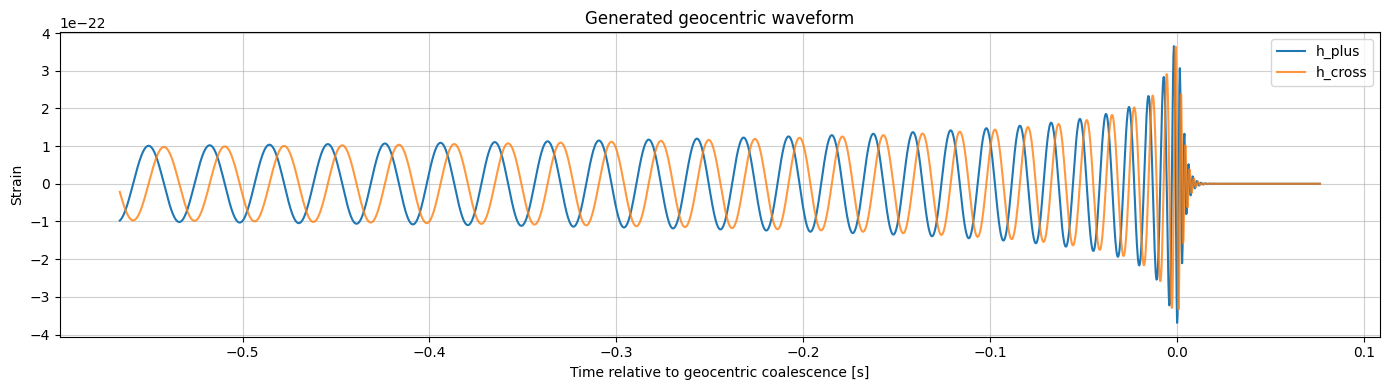

In [12]:
hp = waveform.h_plus
hc = waveform.h_cross

t_hp, y_hp = timeseries_to_arrays(hp)
t_hc, y_hc = timeseries_to_arrays(hc)

plt.figure(figsize=(14, 4))
plt.plot(t_hp, y_hp, label="h_plus")
plt.plot(t_hc, y_hc, label="h_cross", alpha=0.8)
plt.xlabel("Time relative to geocentric coalescence [s]")
plt.ylabel("Strain")
plt.title("Generated geocentric waveform")
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

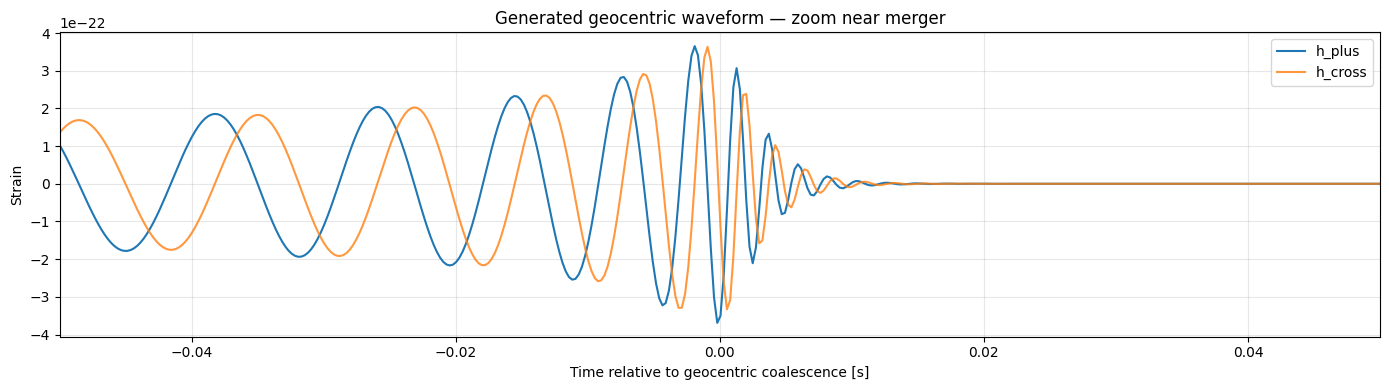

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(t_hp, y_hp, label="h_plus")
plt.plot(t_hc, y_hc, label="h_cross", alpha=0.8)
plt.xlim(-0.05, 0.05)
plt.xlabel("Time relative to geocentric coalescence [s]")
plt.ylabel("Strain")
plt.title("Generated geocentric waveform — zoom near merger")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Project the waveform onto the detector network

The geocentric plus/cross polarizations are projected onto the detector network.

This step applies:

- detector antenna responses;
- sky-location dependence;
- polarization-angle dependence;
- physical detector time delays relative to the geocenter.

The result is a dictionary of detector-frame strains, one per detector.

In [14]:
detector_names = ["H1", "L1", "V1"]
geocentric_coalescence_time = 1126259462.0

projector = DetectorProjector(detector_names=detector_names)

projection = projector.project(
    h_plus=waveform.h_plus,
    h_cross=waveform.h_cross,
    parameters=params,
    geocentric_coalescence_time=geocentric_coalescence_time,
)

projection.metadata

ProjectionMetadata(detector_names=['H1', 'L1', 'V1'], geocentric_coalescence_time=1126259462.0, expected_detector_time_delays={'H1': -0.01778748024381729, 'L1': -0.02111574808831772, 'V1': -0.006068112954319657}, detector_arrival_times={'H1': 1126259461.9822125, 'L1': 1126259461.9788842, 'V1': 1126259461.9939318}, projected_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, projected_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 1126259462.0783691})

In [15]:
print("Expected detector time delays relative to geocenter [s]:")
pprint(projection.metadata.expected_detector_time_delays)

print()
print("Detector arrival times [GPS-like seconds]:")
pprint(projection.metadata.detector_arrival_times)

Expected detector time delays relative to geocenter [s]:
{'H1': -0.01778748024381729,
 'L1': -0.02111574808831772,
 'V1': -0.006068112954319657}

Detector arrival times [GPS-like seconds]:
{'H1': 1126259461.9822125, 'L1': 1126259461.9788842, 'V1': 1126259461.9939318}


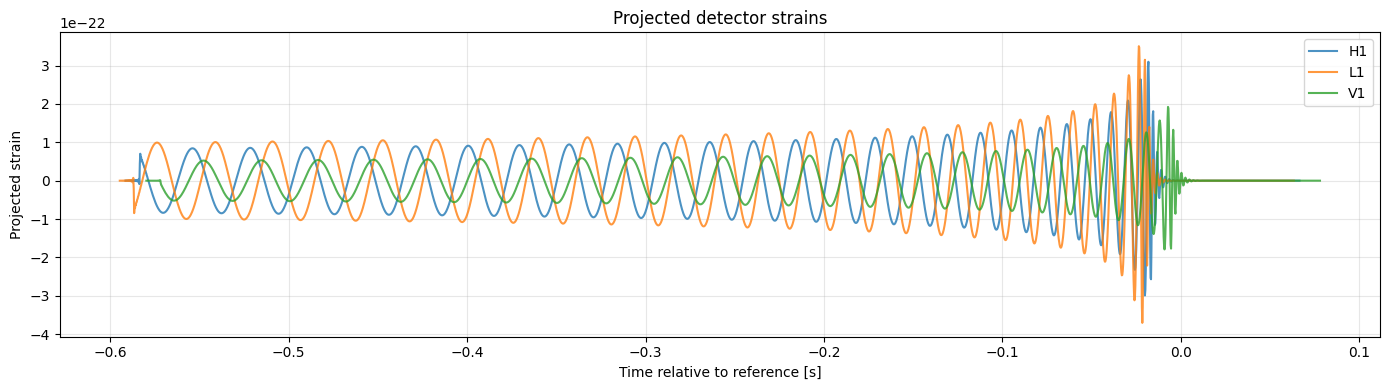

In [16]:
plot_timeseries_dict(
    projection.strains,
    title="Projected detector strains",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
)

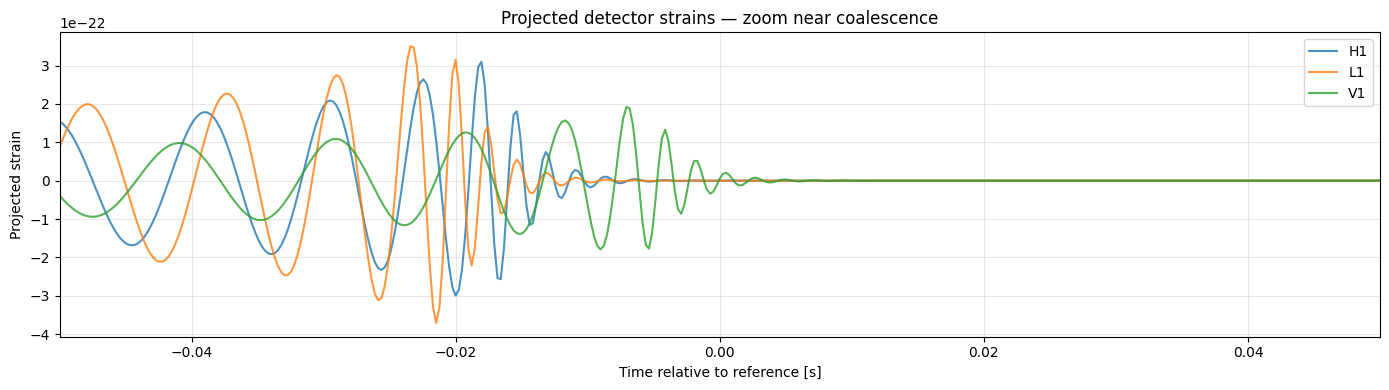

In [17]:
plot_timeseries_dict(
    projection.strains,
    title="Projected detector strains — zoom near coalescence",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
    xlim=(-0.05, 0.05),
)

## 7. Select a common network time window

After projection, the detector strains may not have exactly the same start and end times because the detectors receive the signal with different physical delays.

For this reason, the common network window is selected after projection.

The selected window must be compatible with the fixed segment duration. If the projected network signal is longer than the target duration, the configured truncation policy decides which part is kept.

In [18]:
window_selector = ProjectedNetworkWindowSelector(config=config)

windowed = window_selector.select(
    projected_strains=projection.strains,
    max_duration=config.duration,
)

windowed.metadata

NetworkWindowMetadata(is_truncated=False, truncation_policy='keep_last_segment', detector_names=['H1', 'L1', 'V1'], full_network_start_time=1126259461.4052734, full_network_end_time=1126259462.0783691, full_network_duration=0.673095703125, used_window_start_time=1126259461.4052734, used_window_end_time=1126259462.0783691, used_window_duration=0.673095703125, segment_duration=4.0, max_window_duration=4.0, required_final_duration=1.0, required_available_final_duration=0.673095703125, seconds_before_network_end_in_window=0.673095703125, fraction_network_duration_used=1.0, full_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, full_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 1126259462.0783691}, full_n_samples={'H1': 2697, 'L1': 2697, 'V1': 2696}, used_start_times={'H1': 1126259461.4084473, 'L1': 1126259461.4052734, 'V1': 1126259461.420166}, used_end_times={'H1': 1126259462.0668945, 'L1': 1126259462.0637207, 'V1': 1126259462

In [19]:
print("is_truncated:", windowed.metadata.is_truncated)
print("truncation_policy:", windowed.metadata.truncation_policy)
print("full_network_duration:", windowed.metadata.full_network_duration)
print("used_window_duration:", windowed.metadata.used_window_duration)
print("fraction_network_duration_used:", windowed.metadata.fraction_network_duration_used)
print("seconds_before_network_end_in_window:", windowed.metadata.seconds_before_network_end_in_window)

is_truncated: False
truncation_policy: keep_last_segment
full_network_duration: 0.673095703125
used_window_duration: 0.673095703125
fraction_network_duration_used: 1.0
seconds_before_network_end_in_window: 0.673095703125


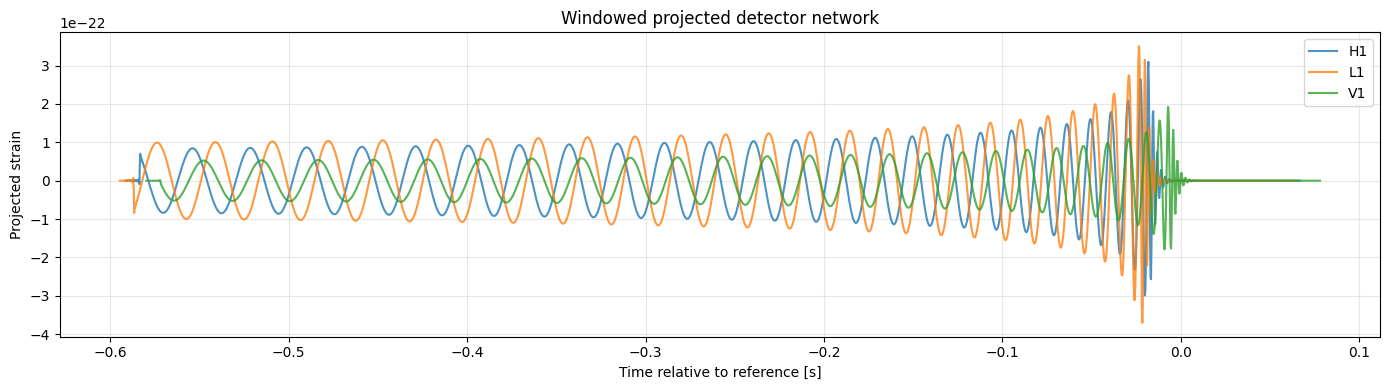

In [20]:
plot_timeseries_dict(
    windowed.strains,
    title="Windowed projected detector network",
    ylabel="Projected strain",
    relative_to=geocentric_coalescence_time,
)

## 8. Place the signal inside a fixed-duration segment

The selected detector-network signal is now placed inside a fixed-duration segment.

This step does not add detector noise yet. It only embeds the signal into zero-valued strain segments with the configured duration.

The resulting signal-only segments are useful for computing the optimal SNR before noise injection.

In [21]:
rng = np.random.default_rng(1234)

injector = SignalInjector(
    config=config,
    rng=rng,
)

placement = injector.choose_segment_placement_containing_network(
    signals=windowed.strains,
    placement_policy="random_contained",
    safe_margin_start=config.safe_margin_start,
    safe_margin_end=config.safe_margin_end,
    enforce_safe_margins=True,
)

placement

SegmentPlacement(segment_start_time=1126259461.3277557, segment_end_time=1126259465.3277557, earliest_signal_start_time=1126259461.4052734, latest_signal_end_time=1126259462.0783691, valid_start_min=1126259458.0783691, valid_start_max=1126259461.4052734, placement_policy='random_contained', signal_network_duration=0.673095703125, safe_margin_start=0.0, safe_margin_end=0.0, margin_before_signal=0.07751774787902832, margin_after_signal=3.2493865489959717, margins_respected=True, enforce_safe_margins=True)

In [22]:
print("segment_start_time:", placement.segment_start_time)
print("segment_end_time:", placement.segment_end_time)
print("earliest_signal_start_time:", placement.earliest_signal_start_time)
print("latest_signal_end_time:", placement.latest_signal_end_time)
print("signal_network_duration:", placement.signal_network_duration)
print("margin_before_signal:", placement.margin_before_signal)
print("margin_after_signal:", placement.margin_after_signal)

segment_start_time: 1126259461.3277557
segment_end_time: 1126259465.3277557
earliest_signal_start_time: 1126259461.4052734
latest_signal_end_time: 1126259462.0783691
signal_network_duration: 0.673095703125
margin_before_signal: 0.07751774787902832
margin_after_signal: 3.2493865489959717


In [23]:
zero_segments = {
    det: injector.build_zero_strain(
        start_time=placement.segment_start_time,
        length=config.length,
    )
    for det in detector_names
}

signal_only_results = injector.inject_network(
    noises=zero_segments,
    signals=windowed.strains,
)

signal_only_segments = {
    det: result.strain
    for det, result in signal_only_results.items()
}

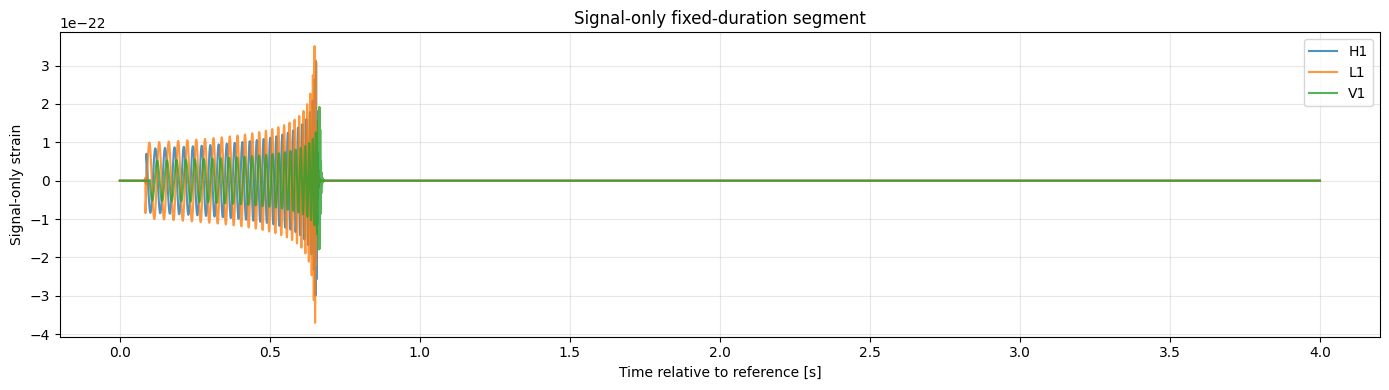

In [24]:
plot_timeseries_dict(
    signal_only_segments,
    title="Signal-only fixed-duration segment",
    ylabel="Signal-only strain",
    relative_to=placement.segment_start_time,
)

## 9. Compute signal-only network SNR

The signal-only fixed-duration segments are used to compute the optimal matched-filter SNR.

The SNR is computed independently for each detector and then combined into a network SNR:

$$
\rho_\mathrm{network} = \sqrt{\sum_i \rho_i^2}
$$

If the network SNR is outside the configured target range, the luminosity distance can be rescaled and the signal regenerated.

In [25]:
noise_model = NoiseModel(config=config)

psds = {
    det: noise_model.get_psd(det)
    for det in detector_names
}

detector_snrs, network_snr = compute_network_optimal_snr(
    signal_segments=signal_only_segments,
    psds=psds,
    config=config,
)

print("Detector SNRs:")
pprint(detector_snrs)

print()
print("Network SNR:", network_snr)

Detector SNRs:
{'H1': 17.134655075762616, 'L1': 20.287888785575745, 'V1': 8.692424285383554}

Network SNR: 27.941959056200293


In [26]:
snr_decision = decide_distance_rescaling(
    current_distance=params.distance,
    current_network_snr=network_snr,
    target_network_snr_range=config.target_network_snr_range,
    rng=rng,
)

snr_decision

SNRRescalingDecision(should_rescale=True, current_network_snr=27.941959056200293, target_network_snr=15.702936025294267, old_distance=1000.0, new_distance=1779.4098512018022, reason='outside_target_range')

In [27]:
print("should_rescale:", snr_decision.should_rescale)
print("reason:", snr_decision.reason)
print("current_network_snr:", snr_decision.current_network_snr)
print("target_network_snr:", snr_decision.target_network_snr)
print("old_distance:", snr_decision.old_distance)
print("new_distance:", snr_decision.new_distance)

should_rescale: True
reason: outside_target_range
current_network_snr: 27.941959056200293
target_network_snr: 15.702936025294267
old_distance: 1000.0
new_distance: 1779.4098512018022


## 10. Rebuild the signal after distance rescaling

If distance rescaling is required, we build a new parameter object with the rescaled distance and regenerate the projected signal network.

This is necessary because the waveform amplitude depends on the luminosity distance.

In [28]:
if snr_decision.should_rescale:
    final_params = params.with_distance(snr_decision.new_distance)
else:
    final_params = params

final_params

CBCParameters(mass_1=20.0, mass_2=20.0, distance=1779.4098512018022, inclination=0.7, ra=1.0, dec=0.5, spin_1z=0.0, spin_2z=0.0, polarization_angle=0.0)

In [29]:
final_waveform = waveform_generator.generate(final_params)

final_projection = projector.project(
    h_plus=final_waveform.h_plus,
    h_cross=final_waveform.h_cross,
    parameters=final_params,
    geocentric_coalescence_time=geocentric_coalescence_time,
)

final_windowed = window_selector.select(
    projected_strains=final_projection.strains,
    max_duration=config.duration,
)

final_placement = injector.choose_segment_placement_containing_network(
    signals=final_windowed.strains,
    placement_policy="random_contained",
    safe_margin_start=config.safe_margin_start,
    safe_margin_end=config.safe_margin_end,
    enforce_safe_margins=True,
)

final_zero_segments = {
    det: injector.build_zero_strain(
        start_time=final_placement.segment_start_time,
        length=config.length,
    )
    for det in detector_names
}

final_signal_only_results = injector.inject_network(
    noises=final_zero_segments,
    signals=final_windowed.strains,
)

final_signal_only_segments = {
    det: result.strain
    for det, result in final_signal_only_results.items()
}

final_detector_snrs, final_network_snr = compute_network_optimal_snr(
    signal_segments=final_signal_only_segments,
    psds=psds,
    config=config,
)

print("Final detector SNRs:")
pprint(final_detector_snrs)

print()
print("Final network SNR:", final_network_snr)

Final detector SNRs:
{'H1': 9.629403290191958, 'L1': 11.401470421147458, 'V1': 4.885004025077612}

Final network SNR: 15.70293602529427


In [30]:
if snr_decision.should_rescale:
    validate_snr_rescaling(
        final_network_snr=final_network_snr,
        target_network_snr=snr_decision.target_network_snr,
        relative_tolerance=config.snr_relative_tolerance,
    )

print("SNR validation passed.")

SNR validation passed.


## 11. Generate detector noise and inject the signal

We now generate Gaussian detector noise from the configured detector PSDs and inject the projected signal into the noise.

This produces the raw noisy strain before whitening, filtering, or cropping.

In [31]:
noises = noise_model.sample_network(
    detector_names=detector_names,
    seed=1234,
    length=config.length,
)

noises = {
    det: injector.set_strain_start_time(
        strain=noise,
        start_time=final_placement.segment_start_time,
        expected_length=config.length,
    )
    for det, noise in noises.items()
}

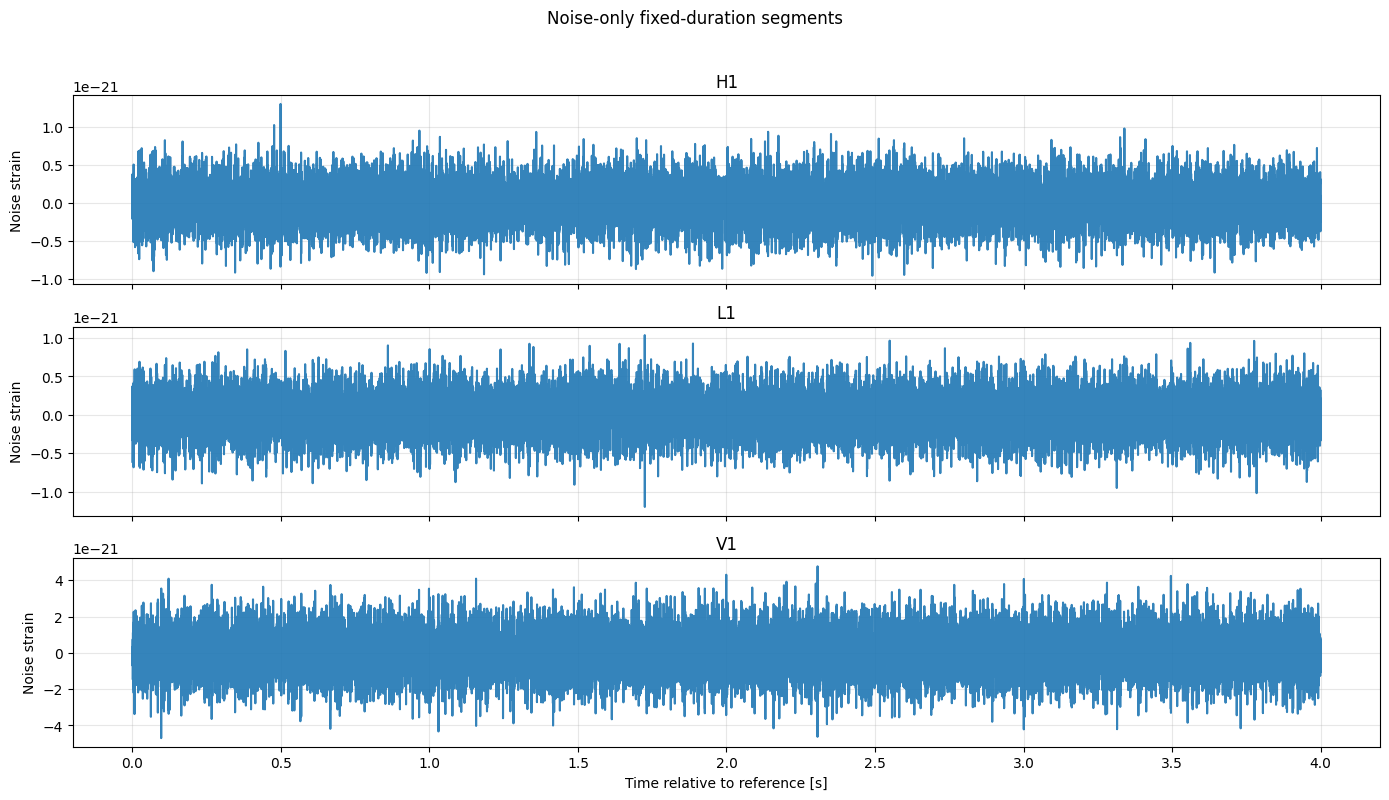

In [32]:
plot_timeseries_dict_subplots(
    noises,
    title="Noise-only fixed-duration segments",
    ylabel="Noise strain",
    relative_to=final_placement.segment_start_time,
)

In [33]:
injected_results = injector.inject_network(
    noises=noises,
    signals=final_windowed.strains,
)

injected_strains = {
    det: result.strain
    for det, result in injected_results.items()
}

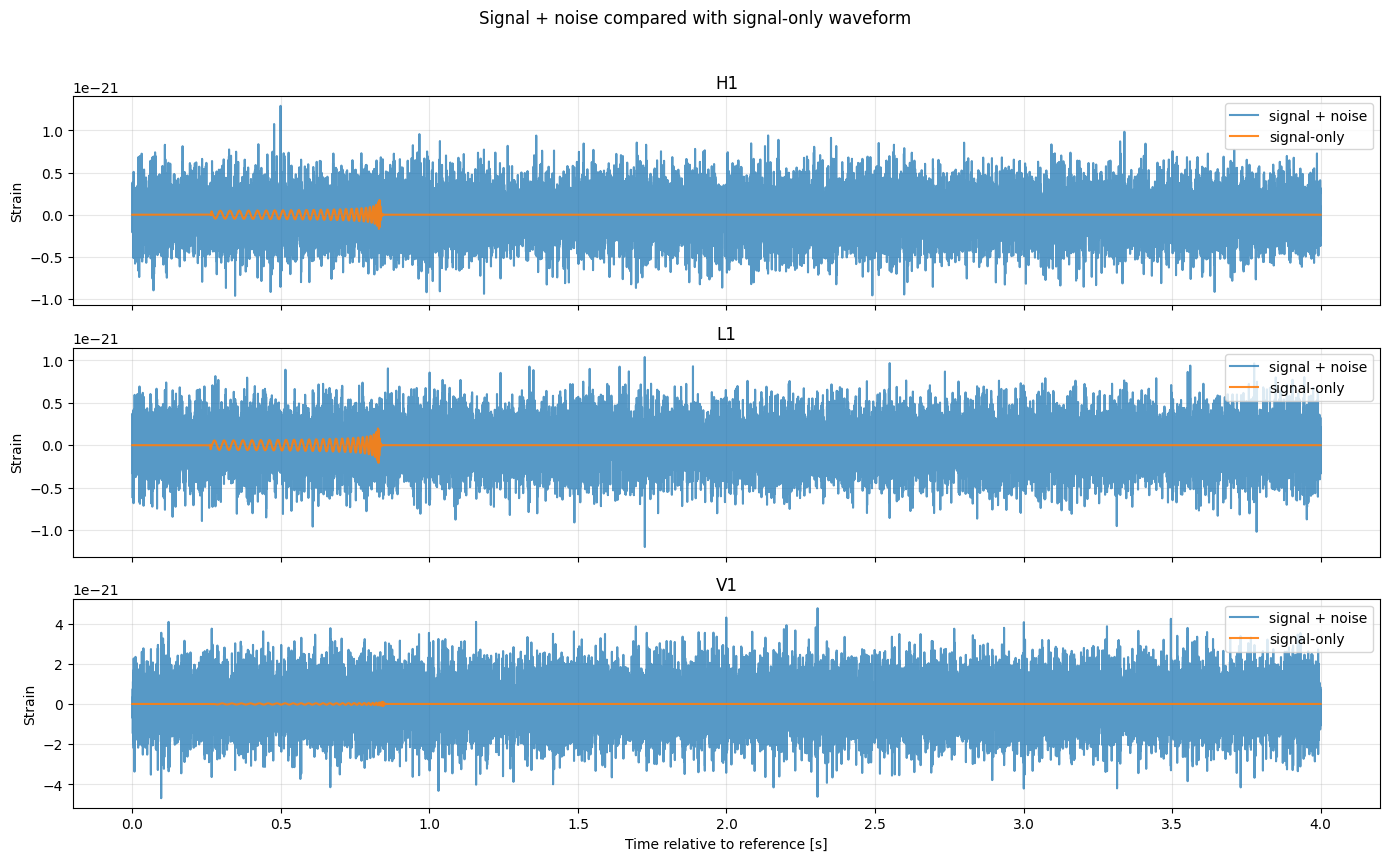

In [34]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise compared with signal-only waveform",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    signal_scale=1.0,
)

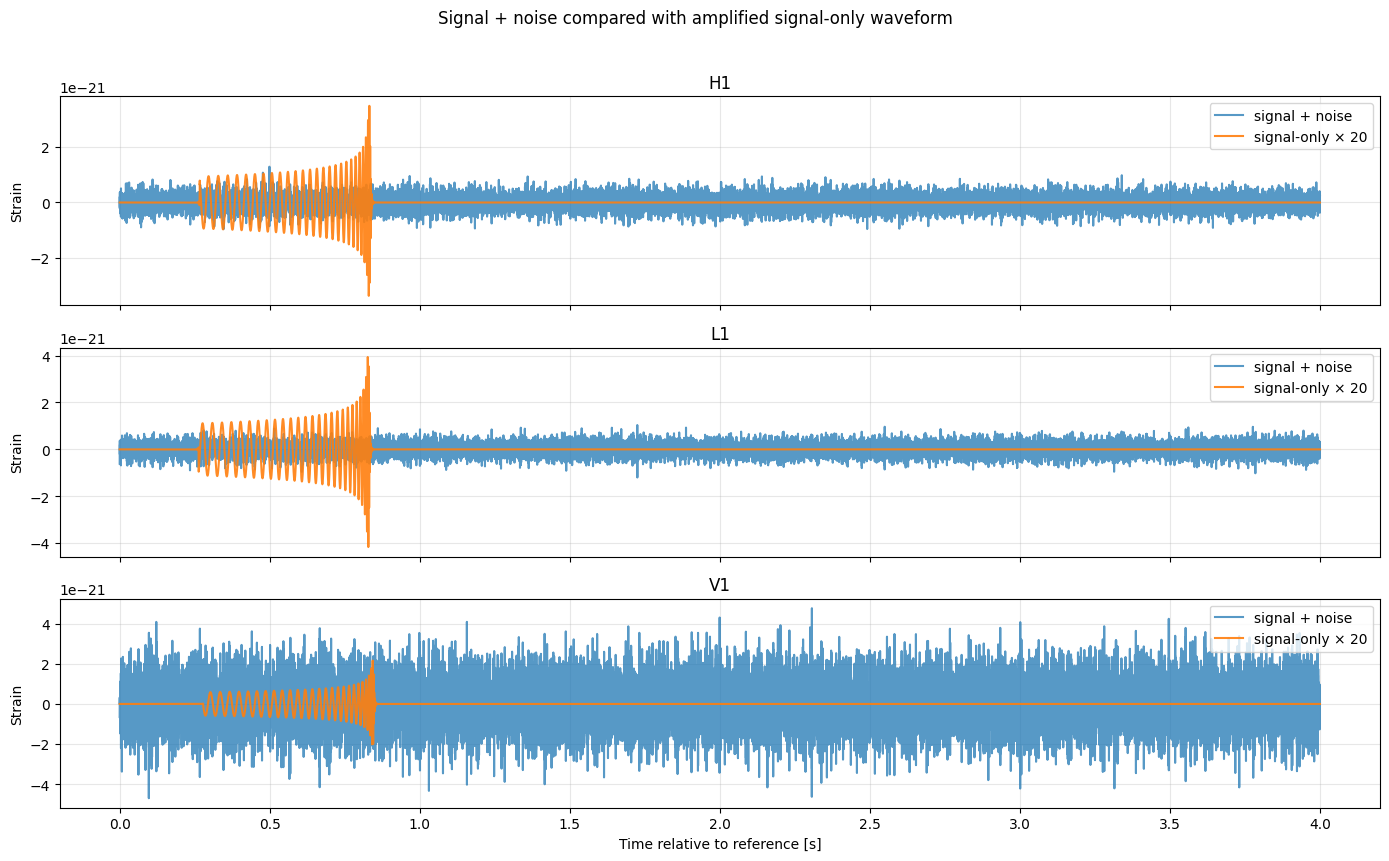

In [35]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise compared with amplified signal-only waveform",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    signal_scale=20.0,
)

In [36]:
# Use the network injection metadata to define a zoom window around the signal.
relative_starts = []
relative_ends = []

for det, result in injected_results.items():
    relative_starts.append(result.signal_start_time - result.segment_start_time)
    relative_ends.append(result.signal_end_time - result.segment_start_time)

zoom_start = max(0.0, min(relative_starts) - 0.5)
zoom_end = min(config.duration, max(relative_ends) + 0.5)

print("zoom_start:", zoom_start)
print("zoom_end:", zoom_end)

zoom_start: 0.0
zoom_end: 1.42844820022583


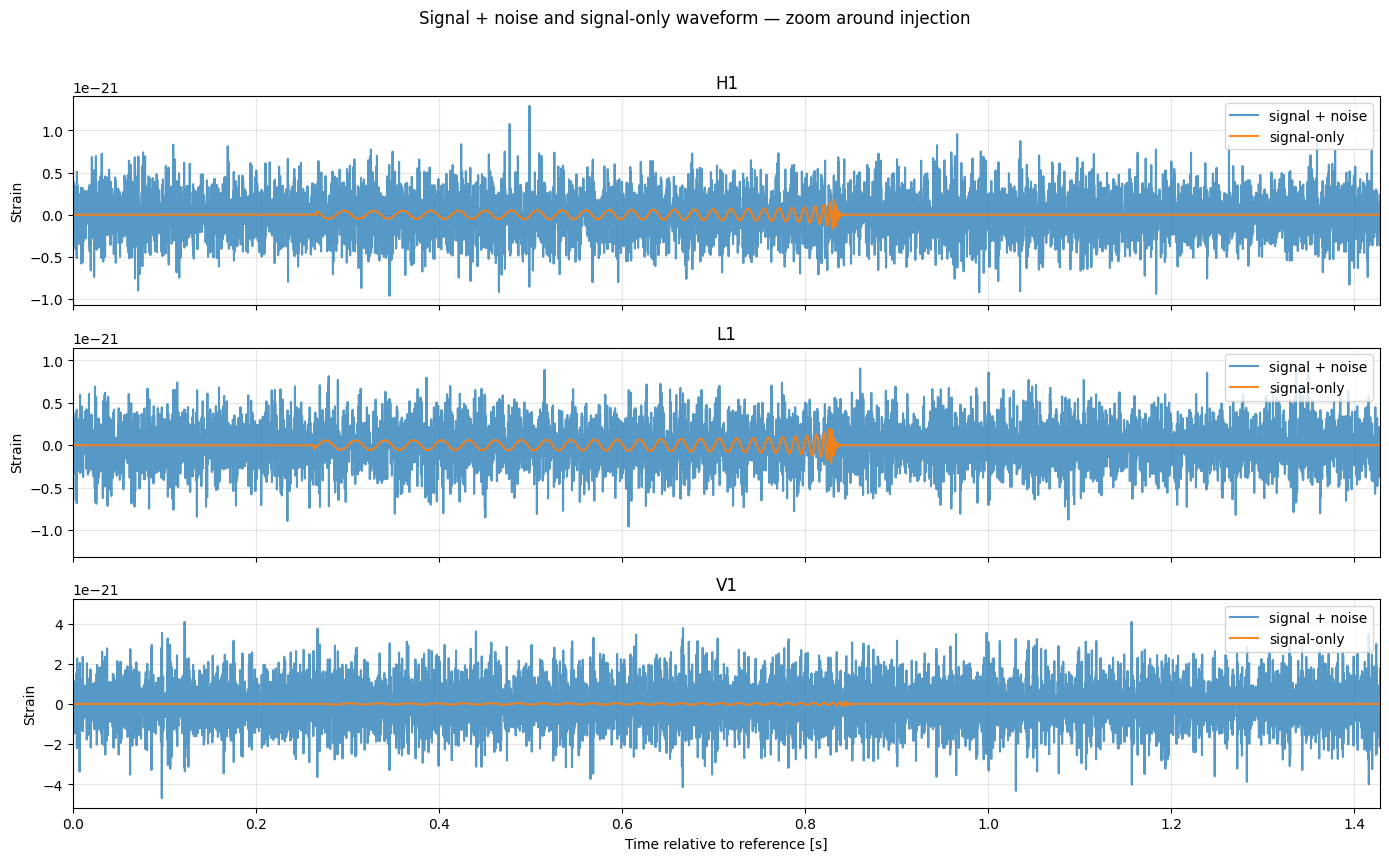

In [37]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise and signal-only waveform — zoom around injection",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    xlim=(zoom_start, zoom_end),
    signal_scale=1.0,
)

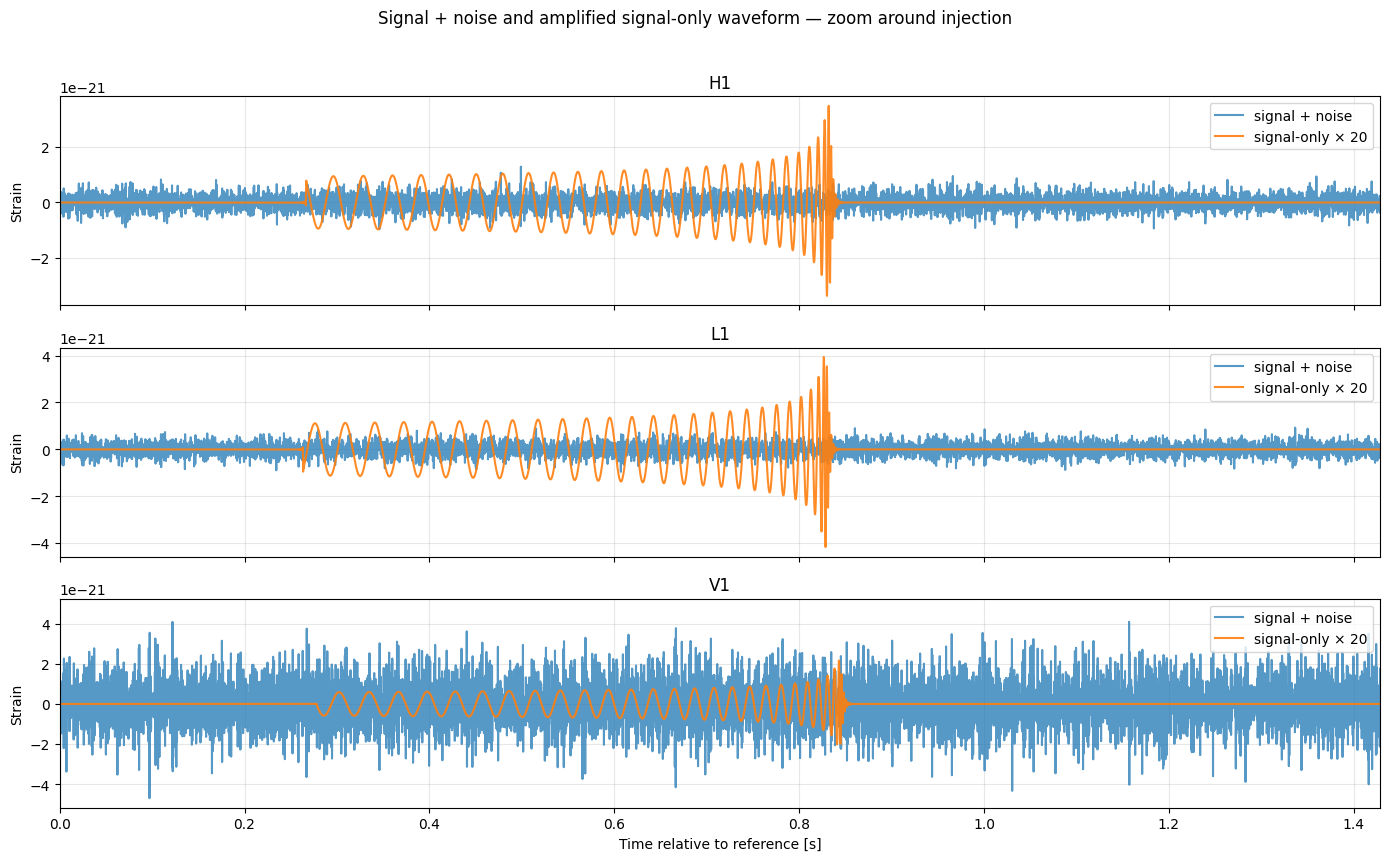

In [38]:
plot_signal_noise_overlay_subplots(
    injected_strains=injected_strains,
    signal_only_segments=final_signal_only_segments,
    title="Signal + noise and amplified signal-only waveform — zoom around injection",
    ylabel="Strain",
    relative_to=final_placement.segment_start_time,
    xlim=(zoom_start, zoom_end),
    signal_scale=20.0,
)

### Detector Metadata

In [39]:
print("Injection metadata for each detector:")

for det, result in injected_results.items():
    print()
    print(det)
    print("  signal_start_time:", result.signal_start_time)
    print("  signal_end_time:", result.signal_end_time)
    print("  segment_start_time:", result.segment_start_time)
    print("  segment_end_time:", result.segment_end_time)
    print("  signal_start_index:", result.signal_start_index)
    print("  signal_end_index:", result.signal_end_index)
    print("  n_signal_samples:", result.n_signal_samples)
    print("  n_injected_samples:", result.n_injected_samples)
    print("  is_partially_clipped:", result.is_partially_clipped)

Injection metadata for each detector:

H1
  signal_start_time: 1126259461.4084473
  signal_end_time: 1126259462.0668945
  segment_start_time: 1126259461.149921
  segment_end_time: 1126259465.149921
  signal_start_index: 1059
  signal_end_index: 3756
  n_signal_samples: 2697
  n_injected_samples: 2697
  is_partially_clipped: False

L1
  signal_start_time: 1126259461.4052734
  signal_end_time: 1126259462.0637207
  segment_start_time: 1126259461.149921
  segment_end_time: 1126259465.149921
  signal_start_index: 1046
  signal_end_index: 3743
  n_signal_samples: 2697
  n_injected_samples: 2697
  is_partially_clipped: False

V1
  signal_start_time: 1126259461.420166
  signal_end_time: 1126259462.0783691
  segment_start_time: 1126259461.149921
  segment_end_time: 1126259465.149921
  signal_start_index: 1107
  signal_end_index: 3803
  n_signal_samples: 2696
  n_injected_samples: 2696
  is_partially_clipped: False


## 12. Process the strain

The final model input is not the raw injected strain.

The configured processing pipeline may include:

- whitening;
- high-pass filtering;
- low-pass filtering;
- optional standardization;
- cropping back to the final fixed-duration output segment.

In the full pipeline, extra processing context is added before and after the final segment so that whitening/filter edge effects are removed outside the returned model input.

### 12.1 Raw processing example

For visualization, we first apply an identity-like processor. This keeps the segment length unchanged and makes it easier to compare raw signal/noise behavior.

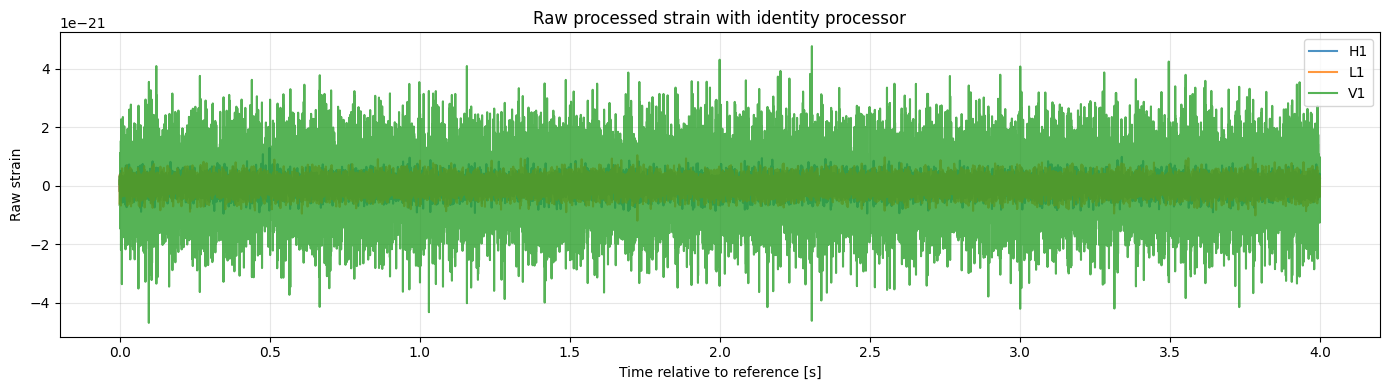

In [40]:
raw_processor = SignalProcessor(
    config=config,
    whitening_method="none",
    apply_highpass=False,
    apply_lowpass=False,
    apply_standardization=False,
    output_mode="restore_length",
)

raw_processed = raw_processor.process_network(
    strains=injected_strains,
    psds=None,
)

plot_timeseries_dict(
    raw_processed,
    title="Raw processed strain with identity processor",
    ylabel="Raw strain",
    relative_to=final_placement.segment_start_time,
)

### 12.2 Full processing through `DatasetBuilder`

The production processing configuration uses a longer processing-context segment and then crops back to the final output window.

Rather than manually rebuilding all context logic here, the recommended way to inspect the complete workflow is to use `DatasetBuilder`.

In [41]:
signal_processor_kwargs = {
    "whitening_method": "psd",
    "apply_highpass": True,
    "apply_lowpass": True,
    "apply_standardization": False,
    "output_mode": "crop_to_config",

    "whitening_low_frequency_cutoff": 30.0,
    "whitening_max_filter_duration": 0.5,
    "whitening_trunc_method": "hann",

    "highpass_frequency": 30.0,
    "lowpass_frequency": 512.0,

    "fir_order": 256,
    "fir_beta": 5.0,
    "remove_corrupted": True,
}

parameter_sampler_kwargs = {
    "regime": "BBH",
    "fixed": {
        "mass_1": 20.0,
        "mass_2": 20.0,
        "spin_1z": 0.0,
        "spin_2z": 0.0,
    },
}

In [42]:
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=detector_names,
    signal_processor_kwargs=signal_processor_kwargs,
    label_transformer_kwargs={},
    parameter_sampler_kwargs=parameter_sampler_kwargs,
    rng=np.random.default_rng(1234),
)

## 13. Build one complete dataset sample

We now use the full builder to generate one complete sample.

This performs the complete workflow:

1. sample or receive physical parameters;
2. generate waveform;
3. project to detectors;
4. select the network window;
5. compute signal-only SNR;
6. rescale distance if needed;
7. generate detector noise with processing context;
8. inject the signal;
9. process the strain;
10. crop to the final fixed-duration segment;
11. build the regression label vector.

In [43]:
sample = builder.build_sample(
    standardize_labels=False,
    geocentric_coalescence_time=geocentric_coalescence_time,
    placement_policy="random_contained",
)

sample

DatasetSample(X=array([[  5.91170294,  11.94439987,  12.3419733 , ..., -39.50118688,
        -28.10669371,  -7.92370392],
       [  9.10736184,   5.69857901,  -0.75682488, ..., -22.37727706,
         -7.95711005,   3.1299733 ],
       [-47.04959945, -48.78436744, -42.72230955, ...,  41.43839824,
         57.8800199 ,  61.67686546]], shape=(3, 16384)), y=array([17.41101127, 40.        ,  0.        ]), parameters=CBCParameters(mass_1=20.0, mass_2=20.0, distance=677.734332593861, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156), metadata={'simulation': {'sampling_frequency': 4096.0, 'duration': 4.0, 'delta_t': 0.000244140625, 'length': 16384, 'delta_f': 0.25, 'flength': 8193, 'low_frequency_cutoff': 30.0, 'waveform_approximant': 'SEOBNRv4_opt', 'target_network_snr_range': (10.0, 25.0), 'snr_relative_tolerance': 0.05, 'truncation_policy': 'keep_last_segment', 'required_final_d

In [44]:
print("X shape:", sample.X.shape)
print("y shape:", sample.y.shape)
print("y:", sample.y)
print()
print("parameters:", sample.parameters)
print()
print("metadata keys:")
print(sample.metadata.keys())

X shape: (3, 16384)
y shape: (3,)
y: [17.41101127 40.          0.        ]

parameters: CBCParameters(mass_1=20.0, mass_2=20.0, distance=677.734332593861, inclination=np.float64(2.06759669959222), ra=2.004945948992312, dec=np.float64(-0.8692072862628579), spin_1z=0.0, spin_2z=0.0, polarization_angle=6.05748854826156)

metadata keys:
dict_keys(['simulation', 'initial_parameters', 'final_parameters', 'geocentric_coalescence_time', 'detectors', 'strain_mode', 'placement_policy', 'waveform', 'windowing', 'projection', 'placement', 'snr', 'injection', 'noise', 'processing', 'processing_context', 'labels'])


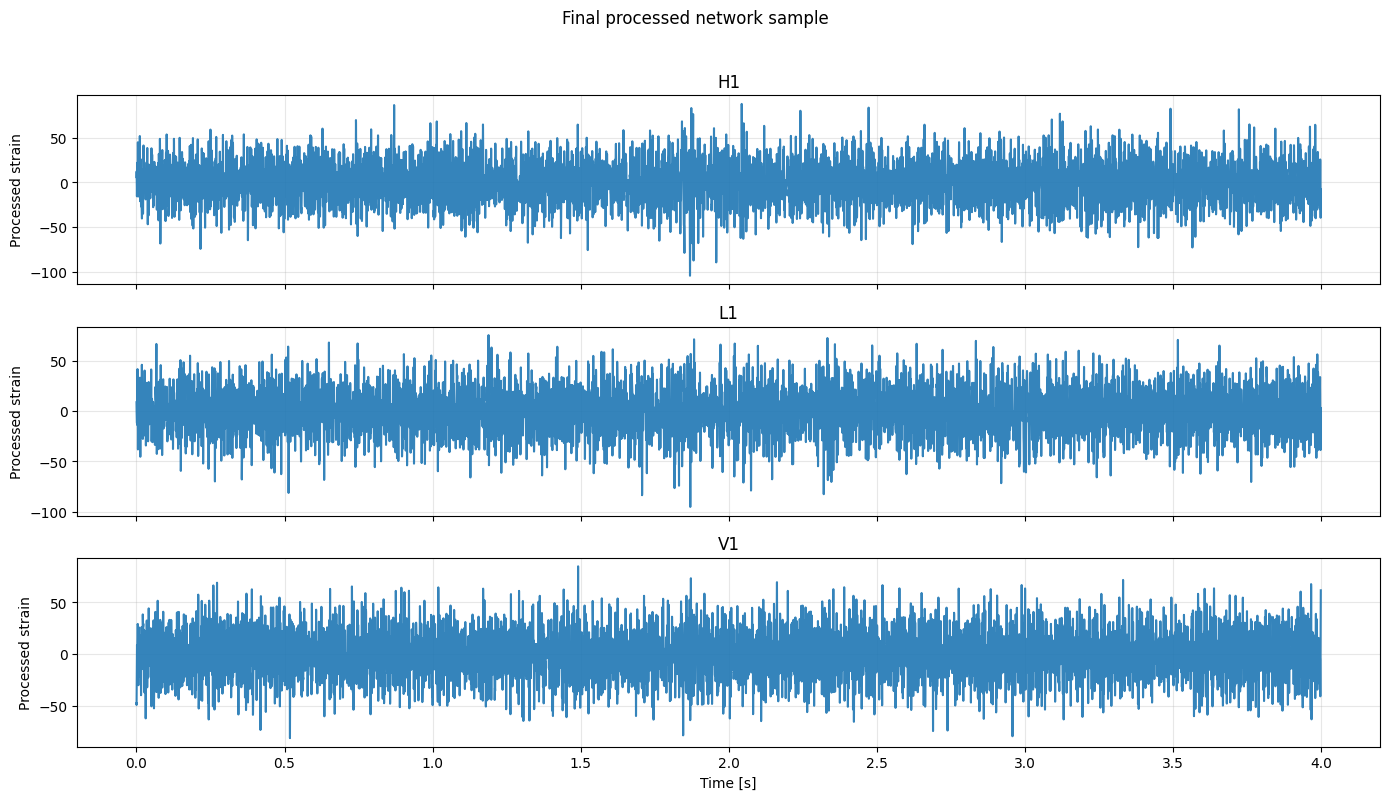

In [45]:
plot_array_network_subplots(
    sample.X,
    detector_names=detector_names,
    sampling_frequency=config.sampling_frequency,
    title="Final processed network sample",
)

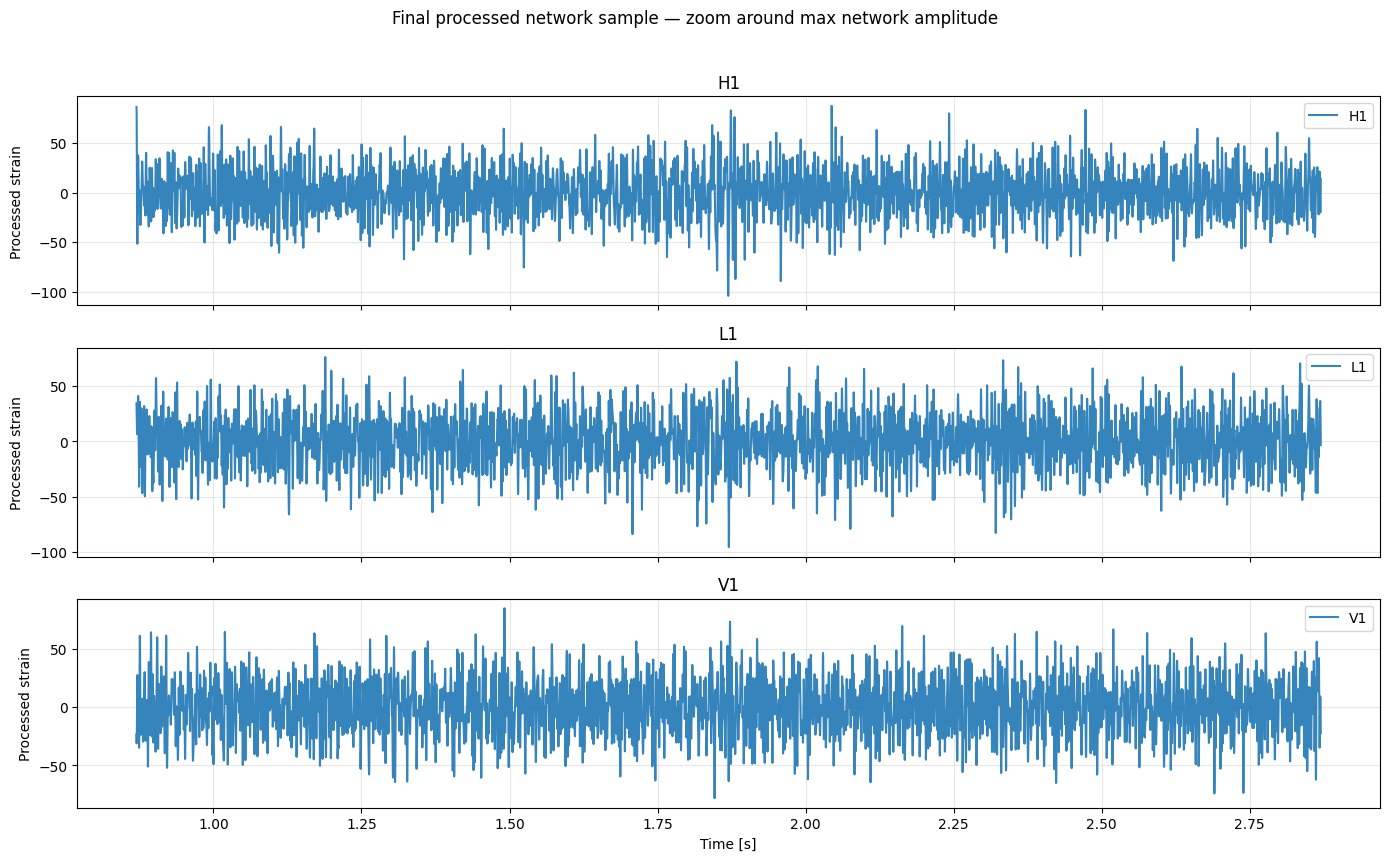

In [46]:
network_abs = np.sqrt(np.sum(sample.X ** 2, axis=0))
peak_idx = int(np.argmax(network_abs))

window_seconds = 2.0
half_window = int(0.5 * window_seconds * config.sampling_frequency)

i0 = max(0, peak_idx - half_window)
i1 = min(sample.X.shape[-1], peak_idx + half_window)

t = np.arange(sample.X.shape[-1]) / config.sampling_frequency

fig, axes = plt.subplots(
    len(detector_names),
    1,
    figsize=(14, 2.8 * len(detector_names)),
    sharex=True,
)

if len(detector_names) == 1:
    axes = [axes]

for det_idx, det in enumerate(detector_names):
    axes[det_idx].plot(
        t[i0:i1],
        sample.X[det_idx, i0:i1],
        label=det,
        alpha=0.9,
    )
    axes[det_idx].set_ylabel("Processed strain")
    axes[det_idx].set_title(det)
    axes[det_idx].grid(alpha=0.3)
    axes[det_idx].legend(loc="upper right")

axes[-1].set_xlabel("Time [s]")

fig.suptitle("Final processed network sample — zoom around max network amplitude", y=1.02)
plt.tight_layout()
plt.show()

## 14. Inspect sample metadata

The sample metadata is useful for debugging, validation, and dataset auditing.

It includes information about:

- simulation configuration;
- initial and final parameters;
- waveform generation;
- detector projection;
- selected window;
- segment placement;
- SNR before and after distance rescaling;
- injection indices and clipping;
- noise and processing configuration;
- label transformation.

In [47]:
print_dict_tree(sample.metadata, max_depth=3)

simulation
  sampling_frequency
    float: 4096.0
  duration
    float: 4.0
  delta_t
    float: 0.000244140625
  length
    int: 16384
  delta_f
    float: 0.25
  flength
    int: 8193
  low_frequency_cutoff
    float: 30.0
  waveform_approximant
    str: SEOBNRv4_opt
  target_network_snr_range
    tuple: (10.0, 25.0)
  snr_relative_tolerance
    float: 0.05
  truncation_policy
    str: keep_last_segment
  required_final_duration
    float: 1.0
  processing_context_start_samples
    int: 1664
  processing_context_end_samples
    int: 1664
  processing_context_start_seconds
    float: 0.40625
  processing_context_end_seconds
    float: 0.40625
  processing_length
    int: 19712
  processing_duration
    float: 4.8125
  processing_delta_f
    float: 0.2077922077922078
  processing_flength
    int: 9857
  simulation_regime
    str: BBH
  waveform_family
    str: IMR
  event_time_reference
    str: geocentric
  snr_on_truncated_signal
    bool: True
initial_parameters
  mass_1
    float: 

In [48]:
print("Simulation metadata:")
pprint(sample.metadata["simulation"])

Simulation metadata:
{'delta_f': 0.25,
 'delta_t': 0.000244140625,
 'duration': 4.0,
 'event_time_reference': 'geocentric',
 'flength': 8193,
 'length': 16384,
 'low_frequency_cutoff': 30.0,
 'processing_context_end_samples': 1664,
 'processing_context_end_seconds': 0.40625,
 'processing_context_start_samples': 1664,
 'processing_context_start_seconds': 0.40625,
 'processing_delta_f': 0.2077922077922078,
 'processing_duration': 4.8125,
 'processing_flength': 9857,
 'processing_length': 19712,
 'required_final_duration': 1.0,
 'sampling_frequency': 4096.0,
 'simulation_regime': 'BBH',
 'snr_on_truncated_signal': True,
 'snr_relative_tolerance': 0.05,
 'target_network_snr_range': (10.0, 25.0),
 'truncation_policy': 'keep_last_segment',
 'waveform_approximant': 'SEOBNRv4_opt',
 'waveform_family': 'IMR'}


In [49]:
print("Initial parameters:")
pprint(sample.metadata["initial_parameters"])

print()
print("Final parameters:")
pprint(sample.metadata["final_parameters"])

Initial parameters:
{'chi_eff': 0.0,
 'chirp_mass': 17.411011265922482,
 'dec': -0.8692072862628579,
 'distance': 4631.581922066986,
 'inclination': 2.06759669959222,
 'mass_1': 20.0,
 'mass_2': 20.0,
 'polarization_angle': 6.05748854826156,
 'ra': 2.004945948992312,
 'spin_1z': 0.0,
 'spin_2z': 0.0,
 'total_mass': 40.0}

Final parameters:
{'chi_eff': 0.0,
 'chirp_mass': 17.411011265922482,
 'dec': -0.8692072862628579,
 'distance': 677.734332593861,
 'inclination': 2.06759669959222,
 'mass_1': 20.0,
 'mass_2': 20.0,
 'polarization_angle': 6.05748854826156,
 'ra': 2.004945948992312,
 'spin_1z': 0.0,
 'spin_2z': 0.0,
 'total_mass': 40.0}


In [50]:
print("SNR metadata:")
pprint(sample.metadata["snr"])

SNR metadata:
{'distance_after_rescale': 677.734332593861,
 'distance_before_rescale': 4631.581922066986,
 'final_detector_snrs': {'H1': 12.61177745487293,
                         'L1': 7.639353682070077,
                         'V1': 7.657977624347493},
 'final_network_snr': 16.615091830802672,
 'initial_detector_snrs': {'H1': 1.8454676436741195,
                           'L1': 1.1178582947002311,
                           'V1': 1.120583515867002},
 'initial_network_snr': 2.4312682712755223,
 'snr_rescaled': True,
 'snr_rescaling_reason': 'outside_target_range',
 'target_network_snr': 16.615091830802672}


In [51]:
print("Placement metadata:")
pprint(sample.metadata["placement"])

Placement metadata:
{'earliest_signal_start_time': 1126259461.4294434,
 'enforce_safe_margins': True,
 'latest_signal_end_time': 1126259462.097168,
 'margin_after_signal': 2.032257556915283,
 'margin_before_signal': 1.3000178337097168,
 'margins_respected': True,
 'placement_policy': 'random_contained',
 'safe_margin_end': 0.0,
 'safe_margin_start': 0.0,
 'segment_end_time': 1126259464.1294255,
 'segment_start_time': 1126259460.1294255,
 'signal_network_duration': 0.667724609375,
 'valid_start_max': 1126259461.4294434,
 'valid_start_min': 1126259458.097168}


In [52]:
print("Injection metadata:")
pprint(sample.metadata["injection"])

Injection metadata:
{'H1': {'is_partially_clipped': False,
        'n_clipped_after': 0,
        'n_clipped_before': 0,
        'n_injected_samples': 2697,
        'n_signal_samples': 2697,
        'overlap_end_index_signal': 2697,
        'overlap_end_index_strain': 9724,
        'overlap_start_index_signal': 0,
        'overlap_start_index_strain': 7027,
        'segment_end_time': 1126259464.5356755,
        'segment_start_time': 1126259459.7231755,
        'signal_end_index': 9724,
        'signal_end_time': 1126259462.097168,
        'signal_start_index': 7027,
        'signal_start_time': 1126259461.4387207},
 'L1': {'is_partially_clipped': False,
        'n_clipped_after': 0,
        'n_clipped_before': 0,
        'n_injected_samples': 2697,
        'n_signal_samples': 2697,
        'overlap_end_index_signal': 2697,
        'overlap_end_index_strain': 9686,
        'overlap_start_index_signal': 0,
        'overlap_start_index_strain': 6989,
        'segment_end_time': 1126259464

In [53]:
for det in detector_names:
    inj = sample.metadata["injection"][det]

    relative_start = inj["signal_start_time"] - inj["segment_start_time"]
    relative_end = inj["signal_end_time"] - inj["segment_start_time"]

    print(det)
    print("  relative signal start [s]:", relative_start)
    print("  relative signal end   [s]:", relative_end)
    print("  signal_start_index:", inj["signal_start_index"])
    print("  signal_end_index:", inj["signal_end_index"])

H1
  relative signal start [s]: 1.7155451774597168
  relative signal end   [s]: 2.373992443084717
  signal_start_index: 7027
  signal_end_index: 9724
L1
  relative signal start [s]: 1.7062678337097168
  relative signal end   [s]: 2.364715099334717
  signal_start_index: 6989
  signal_end_index: 9686
V1
  relative signal start [s]: 1.7062678337097168
  relative signal end   [s]: 2.364470958709717
  signal_start_index: 6989
  signal_end_index: 9685


## 15. Regression labels

The regression target used by the CNN is:

$$
y = [\mathcal{M}_c, M_\mathrm{tot}, \chi_\mathrm{eff}]
$$

where:

- $\mathcal{M}_c$ is the chirp mass;
- $M_\mathrm{tot}$ is the total mass;
- $\chi_\mathrm{eff}$ is the effective aligned spin.

For this demo we use physical labels without standardization. In training, label standardization should use statistics computed from the training set only.

In [54]:
label_transformer = LabelTransformer()

physical_labels = label_transformer.transform(
    sample.parameters,
    standardize=False,
)

print("Label names:", label_transformer.label_names)
print("Physical labels:", physical_labels)

Label names: ('chirp_mass', 'total_mass', 'chi_eff')
Physical labels: [17.41101127 40.          0.        ]


In [55]:
print("From sample.y:")
print(sample.y)

assert np.allclose(sample.y, physical_labels)

From sample.y:
[17.41101127 40.          0.        ]


## 16. Build a tiny batch

Finally, we generate a tiny batch to verify that the same workflow works for more than one sample.

This is still a demo-scale operation. Full datasets should be generated with the script-based HDF5 pipeline.

In [56]:
batch = builder.build_dataset(
    num_samples=2,
    standardize_labels=False,
    geocentric_coalescence_time=geocentric_coalescence_time,
    placement_policy="random_contained",
    progress_every=1,
)

print("X shape:", batch.X.shape)
print("y shape:", batch.y.shape)
print("number of parameter objects:", len(batch.parameters))
print("number of metadata entries:", len(batch.metadata))

Built sample 1 of 2 --> 50.0% completed (attempts=1, failed=0, elapsed=9.3s, 9.33s/sample, 0.11 samples/s)
Built sample 2 of 2 --> 100.0% completed (attempts=2, failed=0, elapsed=15.5s, 7.75s/sample, 0.13 samples/s)
--> DATASET GENERATED with 2 valid samples after 2 attempts. Failed samples: 0 (0.0% failure rate). Total time: 15.5s (7.75s/sample, 0.13 samples/s).
X shape: (2, 3, 16384)
y shape: (2, 3)
number of parameter objects: 2
number of metadata entries: 2


In [57]:
m1 = np.array([p.mass_1 for p in batch.parameters])
m2 = np.array([p.mass_2 for p in batch.parameters])
total_mass = np.array([p.total_mass for p in batch.parameters])
chirp_mass = np.array([p.chirp_mass for p in batch.parameters])
chi_eff = np.array([p.chi_eff for p in batch.parameters])

print("mass_1:", m1)
print("mass_2:", m2)
print("total_mass:", total_mass)
print("chirp_mass:", chirp_mass)
print("chi_eff:", chi_eff)

assert batch.X.shape == (2, len(detector_names), config.length)
assert np.allclose(m1, 20.0)
assert np.allclose(m2, 20.0)
assert np.allclose(chi_eff, 0.0)

mass_1: [20. 20.]
mass_2: [20. 20.]
total_mass: [40. 40.]
chirp_mass: [17.41101127 17.41101127]
chi_eff: [0. 0.]


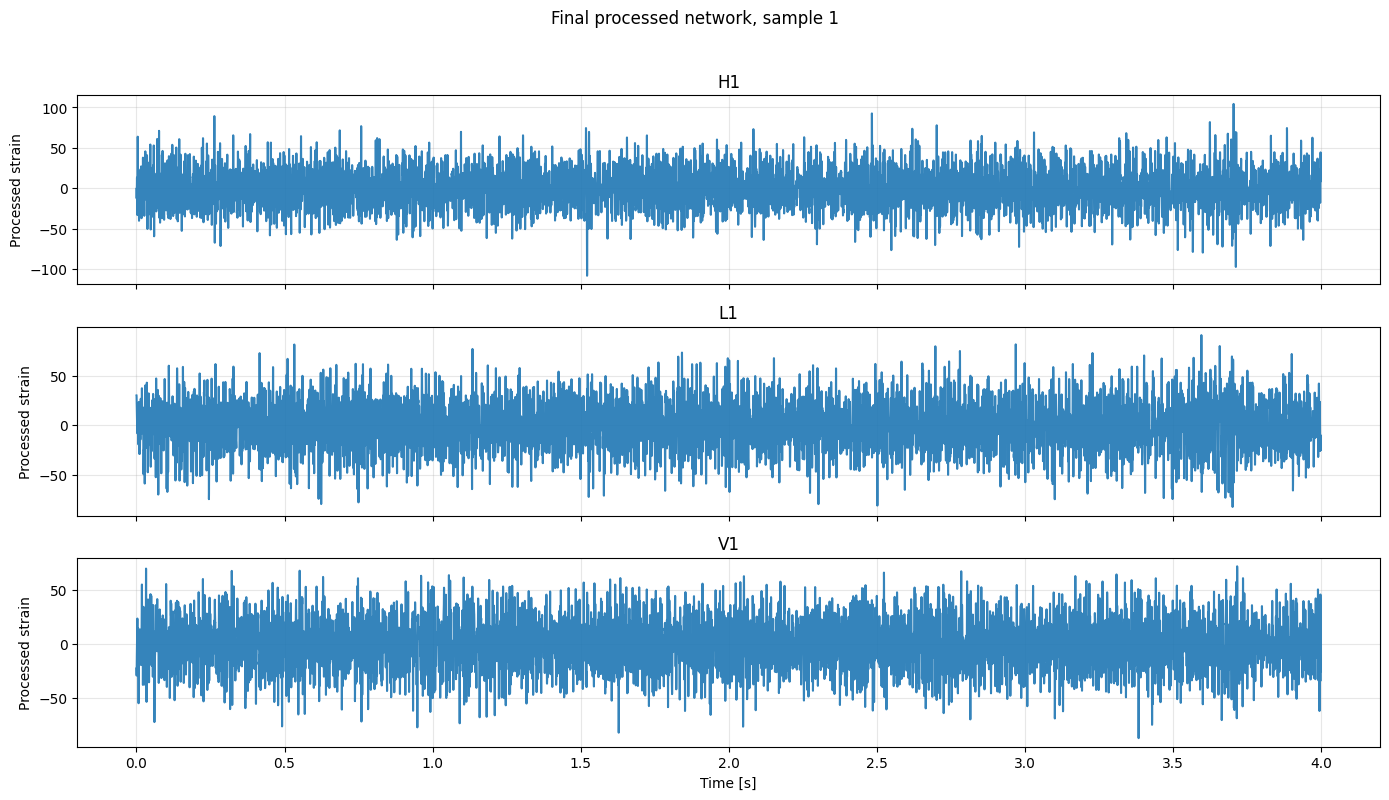

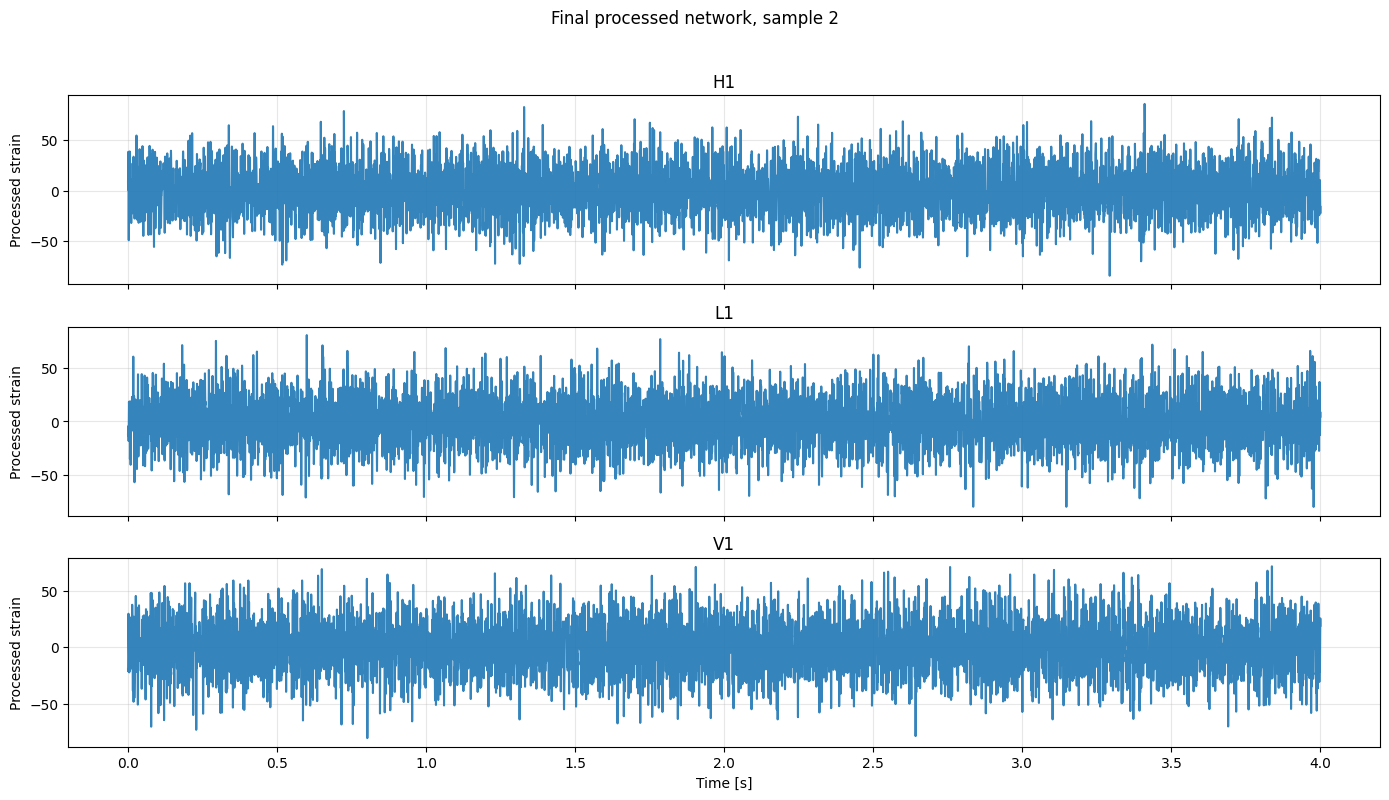

In [58]:
for sample_idx in range(batch.X.shape[0]):
    plot_array_network_subplots(
        batch.X[sample_idx],
        detector_names=detector_names,
        sampling_frequency=config.sampling_frequency,
        title=f"Final processed network, sample {sample_idx + 1}",
    )

## 17. Summary

This notebook walked through the signal-generation workflow step by step.

The main stages were:

1. configure the simulation;
2. define or sample CBC parameters;
3. generate geocentric plus/cross waveforms;
4. project the waveform onto the detector network;
5. select a common detector-network time window;
6. place the signal into a fixed-duration segment;
7. compute signal-only SNR;
8. rescale distance if needed;
9. inject the signal into detector noise;
10. process the noisy strain;
11. build final model-ready samples and labels.

For research-scale generation, use the script-based HDF5 pipeline with versioned JSON configuration files.

## 18. Distributions plots from data (currently 500k)

In [61]:
from pathlib import Path
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Robust path discovery
# -----------------------------
candidate_config_paths = [
    Path("cbc_pe/configs/generation/generate_500k_bbh_4s.json"),
    Path("configs/generation/generate_500k_bbh_4s.json"),
    Path("../configs/generation/generate_500k_bbh_4s.json"),
    Path("../cbc_pe/configs/generation/generate_500k_bbh_4s.json"),
    Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json"),
]

CONFIG_PATH = None

for path in candidate_config_paths:
    if path.exists():
        CONFIG_PATH = path
        break

if CONFIG_PATH is None:
    print("Current working directory:")
    print(Path.cwd())
    raise FileNotFoundError(
        "Could not find generate_500k_bbh_4s.json. "
        "Set CONFIG_PATH manually to the correct absolute path."
    )

print("Using config:", CONFIG_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

data_root = Path(cfg["data_root"])
h5_path = data_root / "processed" / DATASET_ID / cfg["output"]["file_name"]

print("Data root:", data_root)
print("HDF5:", h5_path)

if not h5_path.exists():
    raise FileNotFoundError(
        f"HDF5 file not found: {h5_path}\n"
        "Check whether the dataset is under another data_root, e.g. /data/vserrano/cbc_pe/data or /data/vserrano/cbc_pe_data."
    )

Using config: ../configs/generation/generate_500k_bbh_4s.json
Data root: /data/vserrano/cbc_pe_data
HDF5: /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.h5


In [62]:
# -----------------------------
# Load scalar metadata only
# -----------------------------
def read_group_as_df(h5, group_name):
    group = h5[group_name]
    out = {}
    for key in group.keys():
        obj = group[key]
        if isinstance(obj, h5py.Dataset):
            out[key] = obj[:]
    return pd.DataFrame(out)

with h5py.File(h5_path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("X shape:", f["X"].shape)
    print("y shape:", f["y"].shape)
    print("attrs:")
    for k, v in f.attrs.items():
        print(f"  {k}: {v}")

    params_df = read_group_as_df(f, "parameters")
    snr_df = read_group_as_df(f, "snr")
    
    # Optional extra useful groups
    placement_df = read_group_as_df(f, "placement") if "placement" in f else None
    windowing_df = read_group_as_df(f, "windowing") if "windowing" in f else None

print("parameters:", params_df.shape)
print("snr:", snr_df.shape)

display(params_df.head())
display(snr_df.head())

Top-level keys: ['X', 'generation', 'injection', 'parameters', 'placement', 'projection', 'snr', 'windowing', 'y']
X shape: (500000, 3, 16384)
y shape: (500000, 3)
attrs:
  chunk_size: 2500
  dataset_status: complete
  detector_names: ["H1", "L1", "V1"]
  duration: 4.0
  label_names: ["chirp_mass", "total_mass", "chi_eff"]
  length: 16384
  low_frequency_cutoff: 30.0
  num_samples: 500000
  num_written: 500000
  placement_policy: random_contained
  processing_context_end_samples: 1664
  processing_context_start_samples: 1664
  processing_length: 19712
  sampling_frequency: 4096.0
  seed: 1234
  signal_processor_config: {"whitening_method": "psd", "apply_highpass": true, "apply_lowpass": true, "apply_standardization": false, "output_mode": "crop_to_config", "whitening_low_frequency_cutoff": 30.0, "whitening_max_filter_duration": 0.5, "whitening_trunc_method": "hann", "highpass_frequency": 30.0, "lowpass_frequency": 512.0, "fir_order": 256, "fir_beta": 5.0, "remove_corrupted": true}
  st

,chi_eff,chirp_mass,dec,distance,inclination,mass_1,mass_2,polarization_angle,ra,spin_1z,spin_2z,total_mass
0,-0.470755,49.008739,-0.869207,1201.889404,2.067597,88.019478,37.316639,6.057488,2.004946,-0.516467,-0.362932,125.336121
1,0.022954,60.800541,-0.715331,1727.028564,1.079788,78.419403,62.364910,4.295744,1.399603,0.740830,-0.879723,140.784317
2,0.052073,52.458740,0.799462,2888.344971,3.029600,88.110390,42.310886,5.793368,1.578758,-0.149403,0.471638,130.421280
3,0.067915,19.726051,1.262438,1080.217651,2.024053,44.797913,12.385059,2.327973,5.460663,-0.102253,0.683427,57.182972
4,-0.072770,50.711899,0.525988,2354.771729,1.970340,67.324692,50.608131,4.689379,5.952436,-0.085448,-0.055903,117.932823


,H1,L1,V1,distance_after_rescale,distance_before_rescale,initial_network,network,snr_rescaled,target_network
0,12.674029,7.630803,7.563140,1201.889404,4631.582031,4.311594,16.615091,True,16.615091
1,12.113630,12.866369,7.417822,1727.028564,3367.396973,9.829246,19.165270,True,19.165270
2,14.363626,16.370695,12.037215,2888.344971,2756.456055,26.074512,24.883888,True,24.883888
3,8.090045,6.542996,4.615925,1080.217651,4179.147949,2.942183,11.382723,True,11.382723
4,9.144331,5.368510,4.121399,2354.771729,2354.771729,11.376538,11.376538,False,11.376538


In [64]:
# -----------------------------
# Merge useful metadata
# -----------------------------
df = params_df.copy()

# Prefix SNR columns to avoid ambiguity
for col in snr_df.columns:
    df[f"snr_{col}"] = snr_df[col]

# Derived quantities useful for diagnostics
df["mass_ratio_q"] = df["mass_2"] / df["mass_1"]
df["symmetric_mass_ratio_eta"] = (
    df["mass_1"] * df["mass_2"] / (df["mass_1"] + df["mass_2"])**2
)

df["distance_rescale_factor"] = (
    df["snr_distance_after_rescale"] / df["snr_distance_before_rescale"]
)

df["network_snr_residual_to_target"] = (
    df["snr_network"] - df["snr_target_network"]
)

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
chi_eff,500000.0,0.000978,0.440668,-0.997622,-0.336960,0.000784,0.339507,0.999659
chirp_mass,500000.0,37.468609,16.497301,4.425678,23.909275,36.159204,49.957389,78.300598
dec,500000.0,-0.000481,0.682776,-1.570037,-0.524182,0.000202,0.522115,1.566835
distance,500000.0,1698.925171,1173.663696,26.351162,818.723694,1394.299683,2294.798096,12964.335938
inclination,500000.0,1.570114,0.684115,0.003326,1.045142,1.569153,2.096095,3.138757
mass_1,500000.0,61.671368,20.005898,5.090867,47.523685,65.130623,78.564224,89.999901
mass_2,500000.0,33.345608,20.031254,5.000007,16.389966,29.925683,47.521069,89.933693
polarization_angle,500000.0,3.142047,1.814173,0.000043,1.570990,3.144005,4.712895,6.283173
ra,500000.0,3.140999,1.813789,0.000004,1.570791,3.144473,4.709152,6.283173
spin_1z,500000.0,0.001268,0.577333,-0.999999,-0.498577,0.002860,0.501733,0.999999


In [65]:
# -----------------------------
# Plot style: blue/grey academic palette
# -----------------------------
COLORS = {
    "background": "#F5F7FA",
    "text": "#1F2D3A",
    "title": "#243B53",
    "grid": "#D7DEE8",
    "blue": "#6F91B6",
    "light_blue": "#AFCBE3",
    "dark_blue": "#243B53",
    "teal": "#7FA7A6",
    "sage": "#9CBFA7",
    "rose": "#D8A6A6",
    "sand": "#D9C7A3",
    "gray": "#526D82",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["grid"],
    "axes.labelcolor": COLORS["text"],
    "xtick.color": COLORS["text"],
    "ytick.color": COLORS["text"],
    "text.color": COLORS["text"],
    "axes.titlecolor": COLORS["title"],
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
})

FIG_DIR = Path("figures_dataset_500k")
FIG_DIR.mkdir(exist_ok=True)
print("Saving figures to:", FIG_DIR.resolve())

Saving figures to: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks/figures_dataset_500k


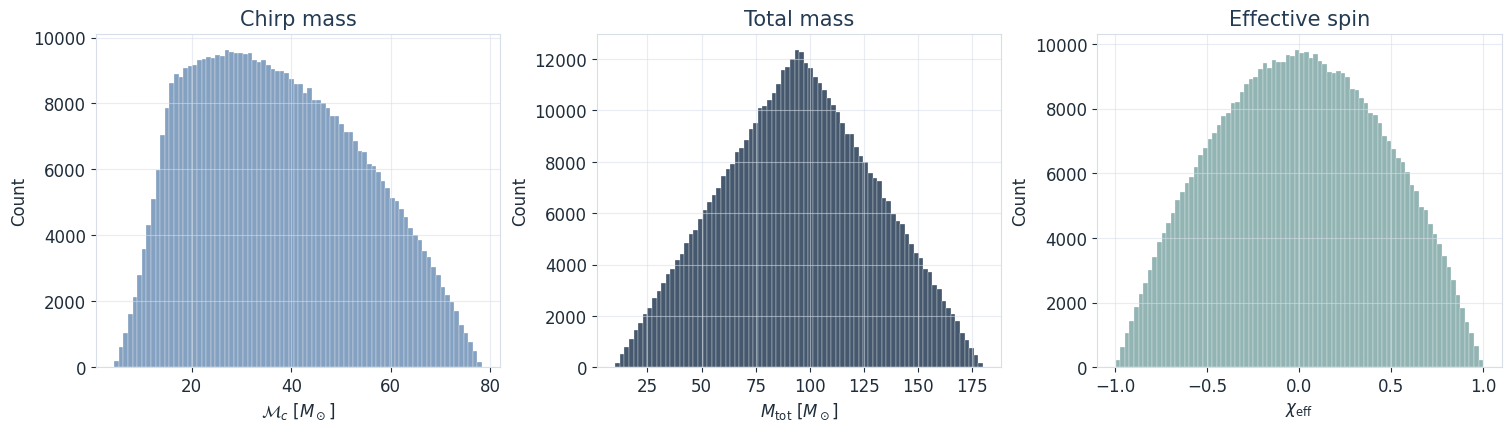

In [106]:
title_names = ["Chirp mass", "Total mass", "Effective spin"]
target_cols = ["chirp_mass", "total_mass", "chi_eff"]
target_labels = [
    r"$\mathcal{M}_c$ [$M_\odot$]",
    r"$M_\mathrm{tot}$ [$M_\odot$]",
    r"$\chi_\mathrm{eff}$",
]
target_colors = [COLORS["blue"], COLORS["dark_blue"], COLORS["teal"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

for ax, col, label, color, name in zip(axes, target_cols, target_labels, target_colors, title_names):
    ax.hist(df[col], bins=80, color=color, alpha=0.85, edgecolor="white", linewidth=0.25)
    ax.set_title(name)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

#fig.suptitle("Parameter-target distributions", fontsize=17, color=COLORS["title"])
fig.savefig(FIG_DIR / "target_parameter_distributions_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "target_parameter_distributions_500k.pdf", bbox_inches="tight")
plt.show()

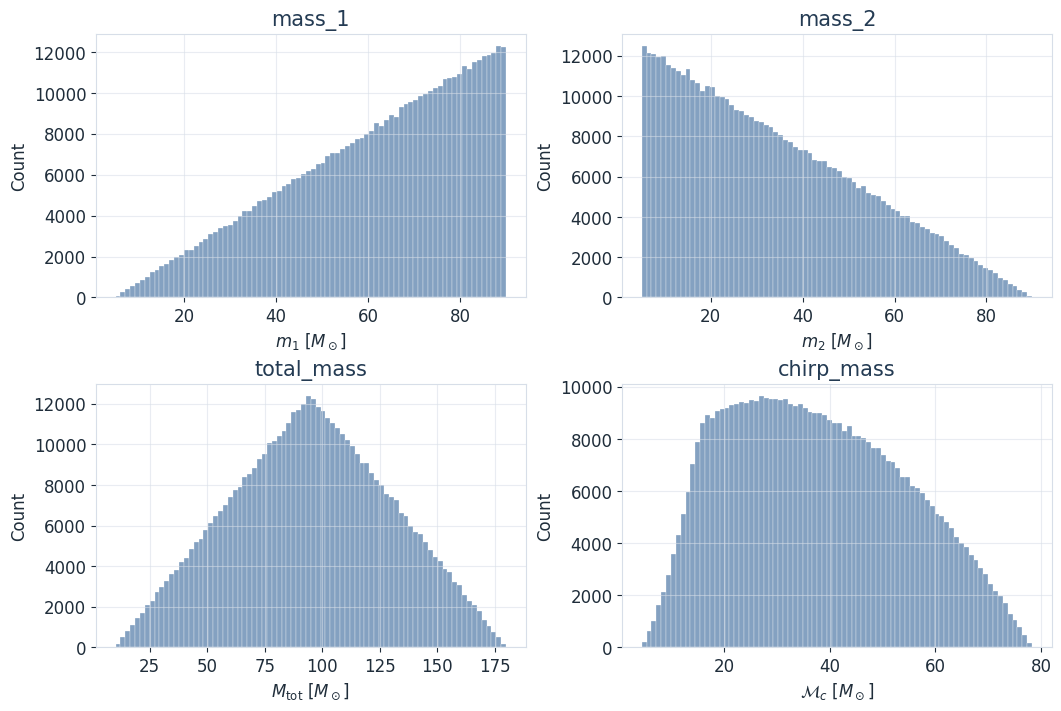

In [105]:
mass_cols = ["mass_1", "mass_2", "total_mass", "chirp_mass"]
mass_labels = [
    r"$m_1$ [$M_\odot$]",
    r"$m_2$ [$M_\odot$]",
    r"$M_\mathrm{tot}$ [$M_\odot$]",
    r"$\mathcal{M}_c$ [$M_\odot$]",
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), constrained_layout=True)
axes = axes.ravel()

for ax, col, label in zip(axes, mass_cols, mass_labels):
    ax.hist(df[col], bins=80, color=COLORS["blue"], alpha=0.85, edgecolor="white", linewidth=0.25)
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

#fig.suptitle("Mass distributions", fontsize=17, color=COLORS["title"])
fig.savefig(FIG_DIR / "mass_distributions_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "mass_distributions_500k.pdf", bbox_inches="tight")
plt.show()

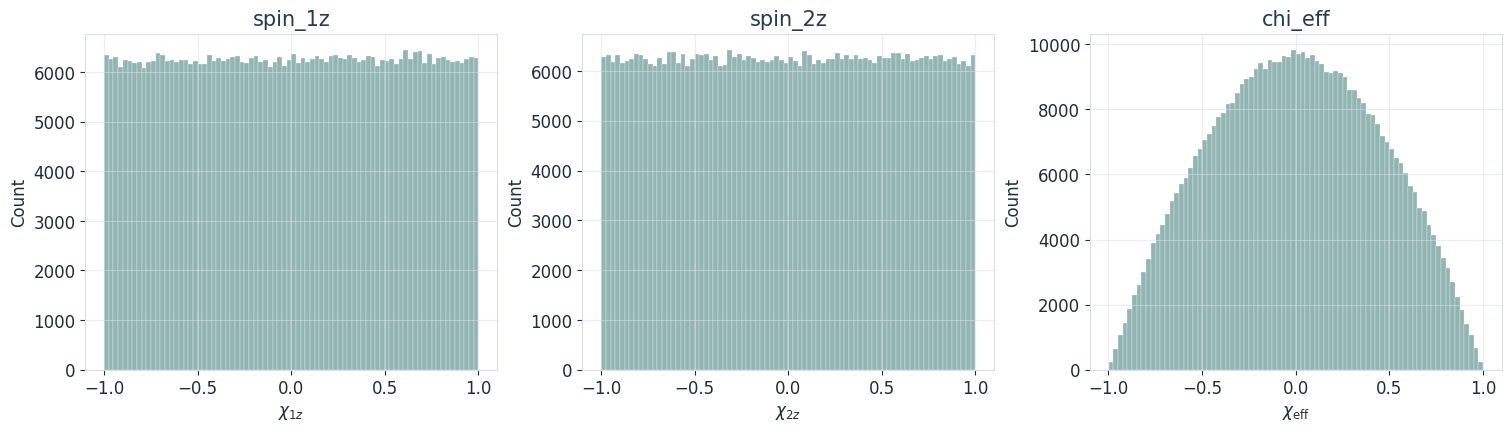

In [107]:
spin_cols = ["spin_1z", "spin_2z", "chi_eff"]
spin_labels = [
    r"$\chi_{1z}$",
    r"$\chi_{2z}$",
    r"$\chi_\mathrm{eff}$",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

for ax, col, label in zip(axes, spin_cols, spin_labels):
    ax.hist(df[col], bins=80, color=COLORS["teal"], alpha=0.85, edgecolor="white", linewidth=0.25)
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

#fig.suptitle("Spin-related parameter distributions", fontsize=17, color=COLORS["title"])
fig.savefig(FIG_DIR / "spin_distributions_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "spin_distributions_500k.pdf", bbox_inches="tight")
plt.show()

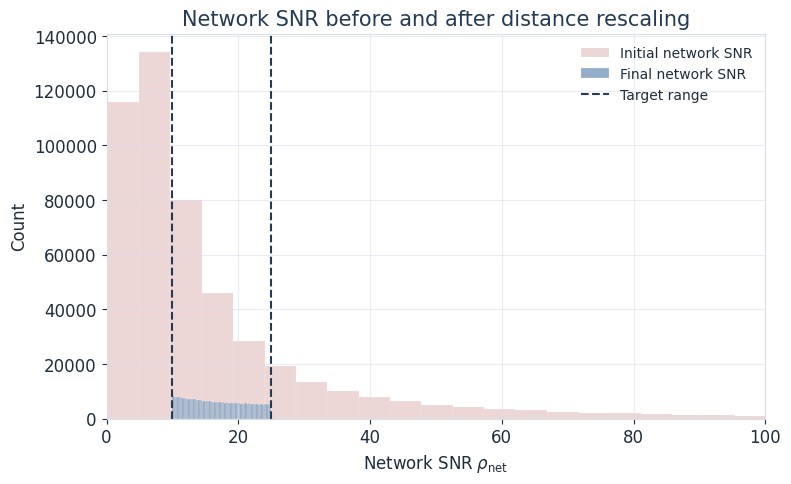

In [86]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.hist(
    df["snr_initial_network"],
    bins=100,
    alpha=0.45,
    label="Initial network SNR",
    color=COLORS["rose"],
    edgecolor="white",
    linewidth=0.2,
)

ax.hist(
    df["snr_network"],
    bins=80,
    alpha=0.75,
    label="Final network SNR",
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.2,
)

ax.axvline(10, color=COLORS["dark_blue"], linestyle="--", linewidth=1.5, label="Target range")
ax.axvline(25, color=COLORS["dark_blue"], linestyle="--", linewidth=1.5)

ax.set_title("Network SNR before and after distance rescaling")
ax.set_xlabel(r"Network SNR $\rho_\mathrm{net}$")
ax.set_ylabel("Count")
ax.set_xlim(0, 100)
ax.legend(frameon=False)

fig.savefig(FIG_DIR / "network_snr_initial_vs_final_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "network_snr_initial_vs_final_500k.pdf", bbox_inches="tight")
plt.show()

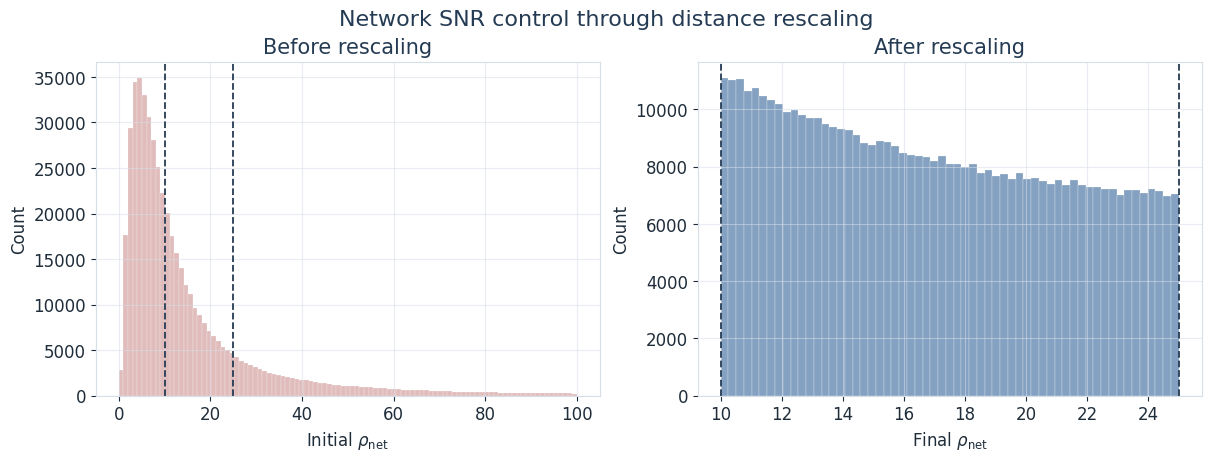

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].hist(
    df["snr_initial_network"],
    bins=np.linspace(0, 100, 100),
    color=COLORS["rose"],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.2,
)
axes[0].axvline(10, color=COLORS["dark_blue"], linestyle="--", linewidth=1.3)
axes[0].axvline(25, color=COLORS["dark_blue"], linestyle="--", linewidth=1.3)
axes[0].set_title("Before rescaling")
axes[0].set_xlabel(r"Initial $\rho_\mathrm{net}$")
axes[0].set_ylabel("Count")

axes[1].hist(
    df["snr_network"],
    bins=np.linspace(10, 25, 60),
    color=COLORS["blue"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.2,
)
axes[1].axvline(10, color=COLORS["dark_blue"], linestyle="--", linewidth=1.3)
axes[1].axvline(25, color=COLORS["dark_blue"], linestyle="--", linewidth=1.3)
axes[1].set_title("After rescaling")
axes[1].set_xlabel(r"Final $\rho_\mathrm{net}$")
axes[1].set_ylabel("Count")

fig.suptitle("Network SNR control through distance rescaling", fontsize=16, color=COLORS["title"])

fig.savefig(FIG_DIR / "distance_before_after_rescaling_2plots_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "distance_before_after_rescaling_2plots_500k.pdf", bbox_inches="tight")
plt.show()

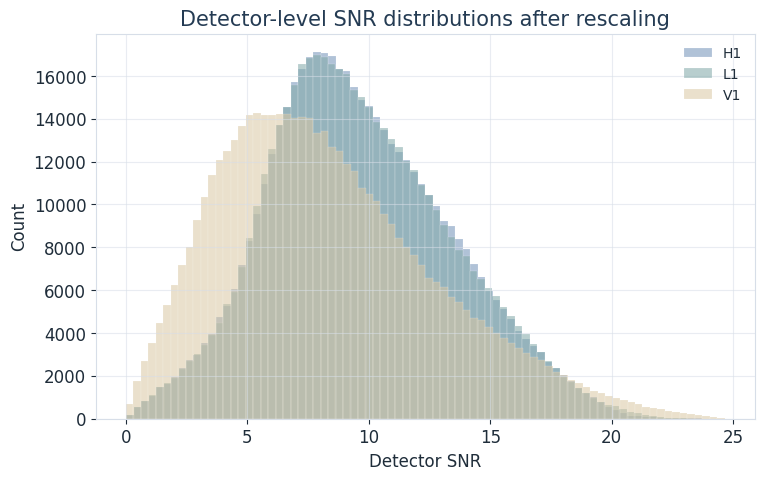

In [97]:
det_snr_cols = ["snr_H1", "snr_L1", "snr_V1"]
det_colors = [COLORS["blue"], COLORS["teal"], COLORS["sand"]]

fig, ax = plt.subplots(figsize=(8.5, 5.0))

for col, color in zip(det_snr_cols, det_colors):
    ax.hist(
        df[col],
        bins=80,
        alpha=0.55,
        label=col.replace("snr_", ""),
        color=color,
        edgecolor="white",
        linewidth=0.2,
    )

ax.set_title("Detector-level SNR distributions after rescaling")
ax.set_xlabel("Detector SNR")
ax.set_ylabel("Count")
ax.legend(frameon=False)

fig.savefig(FIG_DIR / "detector_snr_distributions_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "detector_snr_distributions_500k.pdf", bbox_inches="tight")
plt.show()

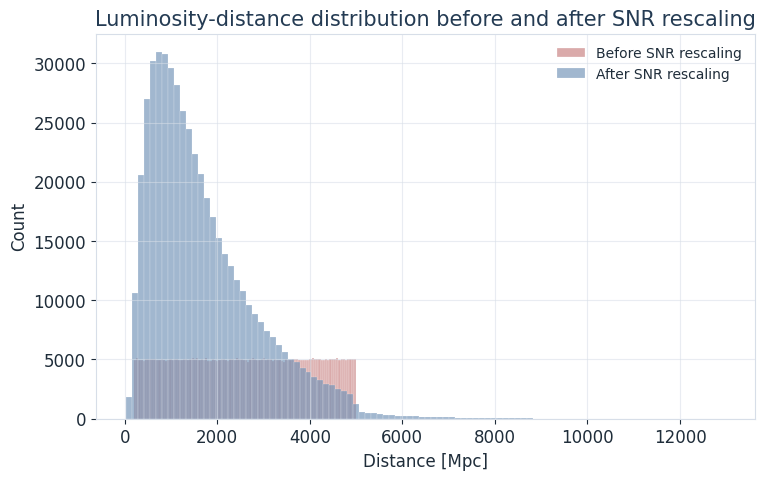

In [76]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.hist(
    df["snr_distance_before_rescale"],
    bins=100,
    alpha=0.95,
    label="Before SNR rescaling",
    color=COLORS["rose"],
    edgecolor="white",
    linewidth=0.2,
)

ax.hist(
    df["snr_distance_after_rescale"],
    bins=100,
    alpha=0.65,
    label="After SNR rescaling",
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.2,
)

ax.set_title("Luminosity-distance distribution before and after SNR rescaling")
ax.set_xlabel("Distance [Mpc]")
ax.set_ylabel("Count")
ax.legend(frameon=False)

fig.savefig(FIG_DIR / "distance_before_after_rescaling_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "distance_before_after_rescaling_500k.pdf", bbox_inches="tight")
plt.show()

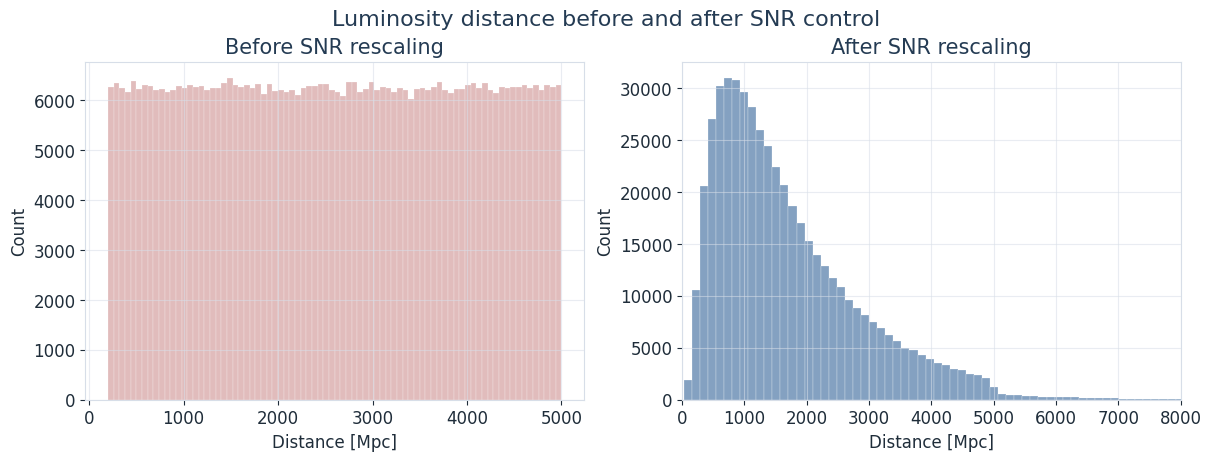

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].hist(
    df["snr_distance_before_rescale"],
    bins=80,
    color=COLORS["rose"],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.2,
)
axes[0].set_title("Before SNR rescaling")
axes[0].set_xlabel("Distance [Mpc]")
axes[0].set_ylabel("Count")

axes[1].hist(
    df["snr_distance_after_rescale"],
    bins=100,
    color=COLORS["blue"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.2,
)
axes[1].set_yscale("linear")
axes[1].set_xlim(0, 8000)
axes[1].set_title("After SNR rescaling")
axes[1].set_xlabel("Distance [Mpc]")
axes[1].set_ylabel("Count")

fig.suptitle("Luminosity distance before and after SNR control", fontsize=16, color=COLORS["title"])

fig.savefig(FIG_DIR / "distance_before_after_rescaling_2plots_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "distance_before_after_rescaling_2plots_500k.pdf", bbox_inches="tight")
plt.show()

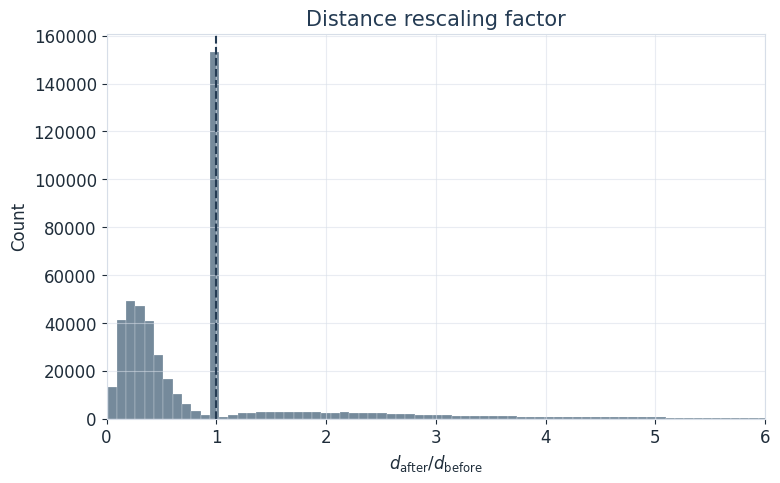

In [81]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.hist(
    df["distance_rescale_factor"],
    bins=500,
    color=COLORS["gray"],
    alpha=0.80,
    edgecolor="white",
    linewidth=0.2,
)

ax.axvline(1.0, color=COLORS["dark_blue"], linestyle="--", linewidth=1.5)

ax.set_title("Distance rescaling factor")
ax.set_xlabel(r"$d_\mathrm{after} / d_\mathrm{before}$")
ax.set_ylabel("Count")
ax.set_xlim(0, 6)

fig.savefig(FIG_DIR / "distance_rescale_factor_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "distance_rescale_factor_500k.pdf", bbox_inches="tight")
plt.show()

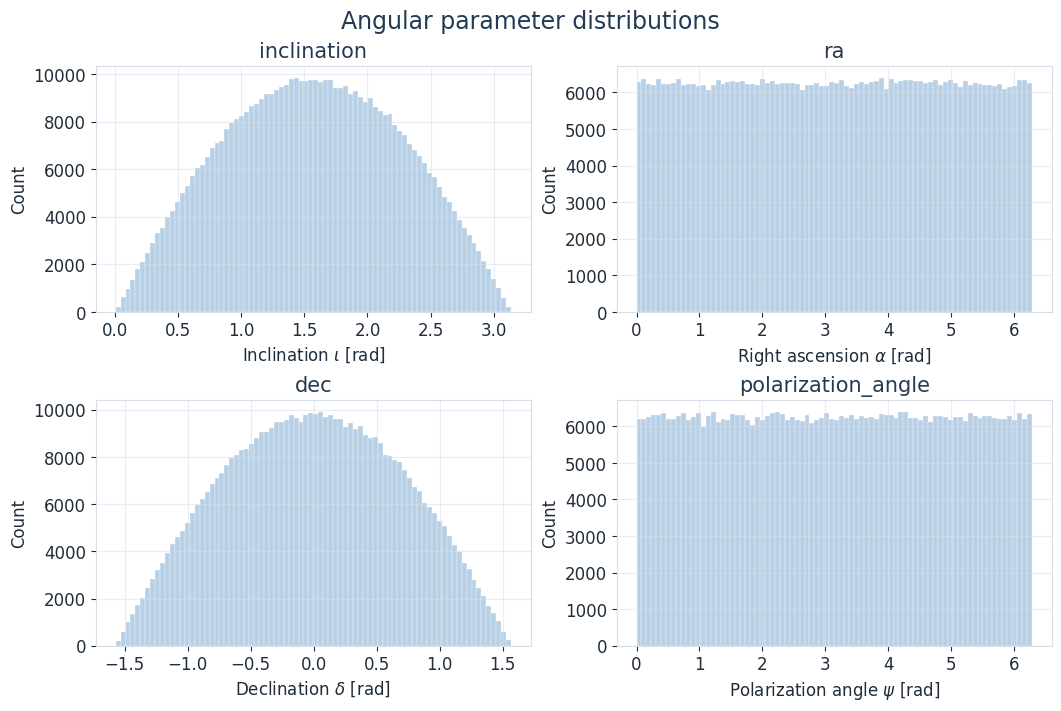

In [82]:
angle_cols = ["inclination", "ra", "dec", "polarization_angle"]
angle_labels = [
    r"Inclination $\iota$ [rad]",
    r"Right ascension $\alpha$ [rad]",
    r"Declination $\delta$ [rad]",
    r"Polarization angle $\psi$ [rad]",
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), constrained_layout=True)
axes = axes.ravel()

for ax, col, label in zip(axes, angle_cols, angle_labels):
    ax.hist(df[col], bins=80, color=COLORS["light_blue"], alpha=0.9, edgecolor="white", linewidth=0.25)
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

fig.suptitle("Angular parameter distributions", fontsize=17, color=COLORS["title"])
fig.savefig(FIG_DIR / "angular_parameter_distributions_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "angular_parameter_distributions_500k.pdf", bbox_inches="tight")
plt.show()

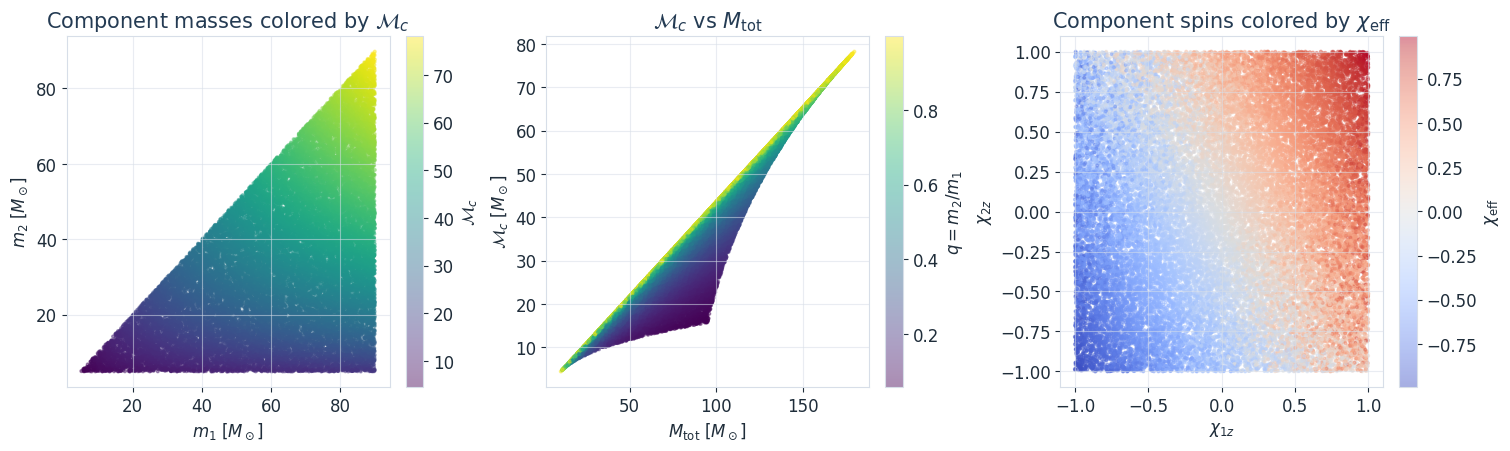

In [83]:
# Downsample for scatter plots to keep files light
rng = np.random.default_rng(123)
n_plot = min(30000, len(df))
idx = rng.choice(len(df), size=n_plot, replace=False)
dsp = df.iloc[idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

sc0 = axes[0].scatter(
    dsp["mass_1"], dsp["mass_2"],
    c=dsp["chirp_mass"], s=4, alpha=0.45, cmap="viridis"
)
axes[0].set_title(r"Component masses colored by $\mathcal{M}_c$")
axes[0].set_xlabel(r"$m_1$ [$M_\odot$]")
axes[0].set_ylabel(r"$m_2$ [$M_\odot$]")
fig.colorbar(sc0, ax=axes[0], label=r"$\mathcal{M}_c$")

sc1 = axes[1].scatter(
    dsp["total_mass"], dsp["chirp_mass"],
    c=dsp["mass_ratio_q"], s=4, alpha=0.45, cmap="viridis"
)
axes[1].set_title(r"$\mathcal{M}_c$ vs $M_\mathrm{tot}$")
axes[1].set_xlabel(r"$M_\mathrm{tot}$ [$M_\odot$]")
axes[1].set_ylabel(r"$\mathcal{M}_c$ [$M_\odot$]")
fig.colorbar(sc1, ax=axes[1], label=r"$q=m_2/m_1$")

sc2 = axes[2].scatter(
    dsp["spin_1z"], dsp["spin_2z"],
    c=dsp["chi_eff"], s=4, alpha=0.45, cmap="coolwarm"
)
axes[2].set_title(r"Component spins colored by $\chi_\mathrm{eff}$")
axes[2].set_xlabel(r"$\chi_{1z}$")
axes[2].set_ylabel(r"$\chi_{2z}$")
fig.colorbar(sc2, ax=axes[2], label=r"$\chi_\mathrm{eff}$")

fig.savefig(FIG_DIR / "physical_parameter_correlations_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "physical_parameter_correlations_500k.pdf", bbox_inches="tight")
plt.show()

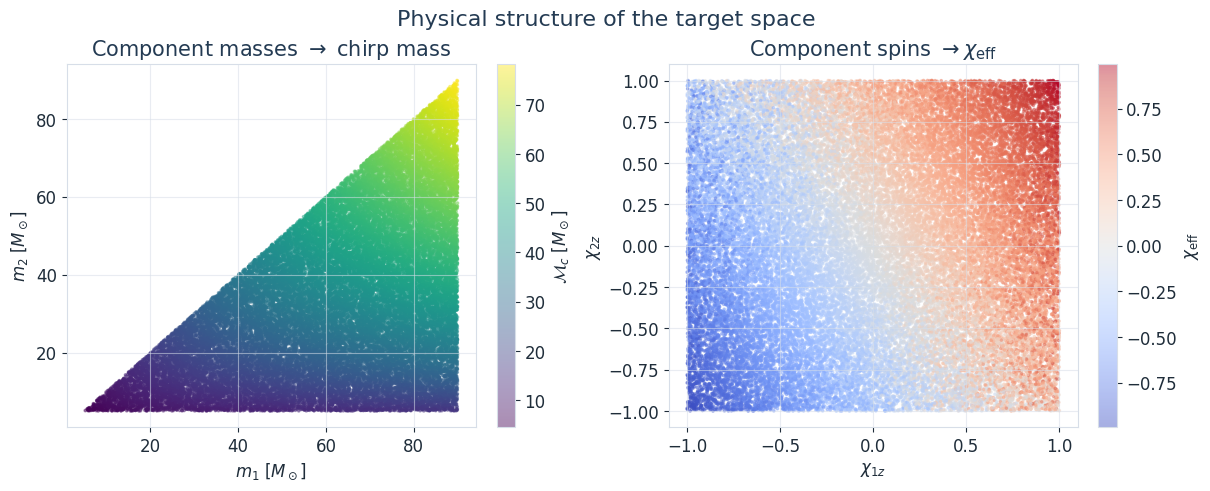

In [95]:
rng = np.random.default_rng(123)
n_plot = min(40000, len(df))
idx = rng.choice(len(df), size=n_plot, replace=False)
dsp = df.iloc[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

sc0 = axes[0].scatter(
    dsp["mass_1"],
    dsp["mass_2"],
    c=dsp["chirp_mass"],
    s=3,
    alpha=0.45,
    cmap="viridis",
    rasterized=True,
)
axes[0].set_title(r"Component masses $\rightarrow$ chirp mass")
axes[0].set_xlabel(r"$m_1$ [$M_\odot$]")
axes[0].set_ylabel(r"$m_2$ [$M_\odot$]")
cb0 = fig.colorbar(sc0, ax=axes[0])
cb0.set_label(r"$\mathcal{M}_c$ [$M_\odot$]")

sc1 = axes[1].scatter(
    dsp["spin_1z"],
    dsp["spin_2z"],
    c=dsp["chi_eff"],
    s=3,
    alpha=0.45,
    cmap="coolwarm",
    rasterized=True,
)
axes[1].set_title(r"Component spins $\rightarrow \chi_\mathrm{eff}$")
axes[1].set_xlabel(r"$\chi_{1z}$")
axes[1].set_ylabel(r"$\chi_{2z}$")
cb1 = fig.colorbar(sc1, ax=axes[1])
cb1.set_label(r"$\chi_\mathrm{eff}$")

fig.suptitle(
    "Physical structure of the target space",
    fontsize=16,
    color=COLORS["title"],
)

fig.savefig(FIG_DIR / "physical_target_space_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "physical_target_space_500k.pdf", bbox_inches="tight")

plt.show()

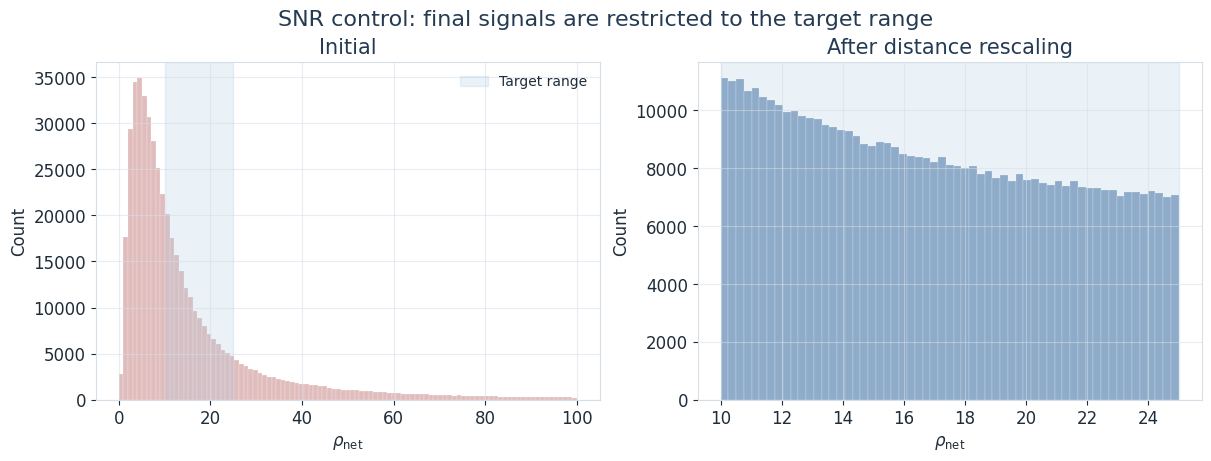

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].hist(
    df["snr_initial_network"],
    bins=np.linspace(0, 100, 100),
    color=COLORS["rose"],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.2,
)
axes[0].axvspan(10, 25, color=COLORS["light_blue"], alpha=0.25, label="Target range")
axes[0].set_title("Initial")
axes[0].set_xlabel(r"$\rho_\mathrm{net}$")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)

axes[1].hist(
    df["snr_network"],
    bins=np.linspace(10, 25, 60),
    color=COLORS["blue"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.2,
)
axes[1].axvspan(10, 25, color=COLORS["light_blue"], alpha=0.25)
axes[1].set_title("After distance rescaling")
axes[1].set_xlabel(r"$\rho_\mathrm{net}$")
axes[1].set_ylabel("Count")

fig.suptitle(
    "SNR control: final signals are restricted to the target range",
    fontsize=16,
    color=COLORS["title"],
)

fig.savefig(FIG_DIR / "snr_control_two_panel_500k.png", dpi=250, bbox_inches="tight")
fig.savefig(FIG_DIR / "snr_control_two_panel_500k.pdf", bbox_inches="tight")

plt.show()

In [84]:
summary_cols = [
    "mass_1", "mass_2", "total_mass", "chirp_mass", "chi_eff",
    "distance", "snr_initial_network", "snr_network",
    "snr_distance_before_rescale", "snr_distance_after_rescale",
]

summary = df[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
summary = summary[["mean", "std", "min", "1%", "5%", "50%", "95%", "99%", "max"]]

display(summary)

summary.to_csv(FIG_DIR / "dataset_500k_parameter_summary.csv")
summary.round(4).to_latex(FIG_DIR / "dataset_500k_parameter_summary.tex")

,mean,std,min,1%,5%,50%,95%,99%,max
mass_1,61.671368,20.005898,5.090867,13.519555,24.077560,65.130623,87.837269,89.571893,89.999901
mass_2,33.345608,20.031254,5.000007,5.423150,7.157569,29.925683,70.932377,81.469995,89.933693
total_mass,95.016960,34.667393,10.167550,22.014761,36.922571,94.984299,153.105355,167.883531,179.887543
chirp_mass,37.468609,16.497301,4.425678,8.811925,13.313441,36.159204,66.247876,73.000355,78.300598
chi_eff,0.000978,0.440668,-0.997622,-0.876085,-0.720979,0.000784,0.722803,0.877249,0.999659
distance,1698.925171,1173.663696,26.351162,211.258776,370.155733,1394.299683,4067.279077,5084.548887,12964.335938
snr_initial_network,17.989113,26.219543,0.186154,1.207792,2.192973,9.711999,62.947101,136.511381,476.251801
snr_network,16.902428,4.358193,10.000003,10.113291,10.575216,16.591316,24.103432,24.818411,24.999964
snr_distance_before_rescale,2599.235352,1386.711914,200.005081,248.285189,440.028145,2596.851807,4760.691284,4952.426895,4999.974121
snr_distance_after_rescale,1698.925171,1173.663696,26.351162,211.258776,370.155733,1394.299683,4067.279077,5084.548887,12964.335938
